<a href="https://colab.research.google.com/github/jieun0441/scaling_Korea/blob/main/Grid_Data_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Data Structure check
import pandas as pd
import glob

# 데이터가 있는 폴더 경로를 실제 환경에 맞게 지정합니다.
file_path = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/Pop500x500/*.csv'
csv_files = glob.glob(file_path)

if csv_files:
    # 첫 번째 파일만 선택하여 상위 5행 로드
    sample_file = csv_files[0]
    df_sample = pd.read_csv(sample_file, nrows=5, encoding='euc-kr')

    # 데이터 구조 출력
    print(list(df_sample.columns))
    print(df_sample)
else:
    print("지정된 경로에 CSV 파일이 없습니다.")

['2015', '다라00a07b', 'to_in_001', '5']
   2015  다라00a07b  to_in_001  5
0  2015  다라00a07b  to_in_007  5
1  2015  다라00a07b  to_in_008  0
2  2015  다라00a17b  to_in_001  0
3  2015  다라00a17b  to_in_007  0
4  2015  다라00a17b  to_in_008  0


In [ ]:
import pandas as pd
import glob
import geopandas as gpd

file_path = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/Pop500x500/*.csv'
csv_files = glob.glob(file_path)

# 1. 폴더 내 전체 CSV 파일 개수 확인
print(f"탐색된 전체 CSV 파일 개수: {len(csv_files)}개")

df_list = []

for file in csv_files:
    # 헤더 없음 명시 및 컬럼명 직접 할당
    df = pd.read_csv(
        file,
        encoding='euc-kr',
        header=None,
        names=['year', 'grid_id', 'pop_type', 'population']
    )

    # 총인구(to_in_001) 데이터만 필터링
    df_filtered = df[df['pop_type'] == 'to_in_001'].copy()

    # 불필요한 pop_type 컬럼 제거
    df_filtered.drop(columns=['pop_type'], inplace=True)

    df_list.append(df_filtered)

# 2. 실제 병합 단계로 넘어간 데이터프레임 개수 확인
print(f"병합 대상 데이터프레임 개수: {len(df_list)}개")


# 전체 데이터 병합
merged_df = pd.concat(df_list, ignore_index=True)

# 피벗 테이블 생성 (행: 격자 ID, 열: 연도, 값: 총인구)
# 격자 ID별 연도 데이터 중복 가능성을 배제하기 위해 pivot_table 사용
pivot_df = merged_df.pivot_table(
    index='grid_id',
    columns='year',
    values='population',
    aggfunc='sum'
)


탐색된 전체 CSV 파일 개수: 390개
병합 대상 데이터프레임 개수: 390개


In [ ]:
# --- 결측치 확인 로직 시작 ---

# 1. 연도별 결측치 개수
missing_counts = pivot_df.isna().sum()
print("연도별 결측치 개수:\n", missing_counts)

# 2. 연도별 결측치 비율(%)
missing_ratio = pivot_df.isna().mean() * 100
print("\n연도별 결측치 비율(%):\n", missing_ratio.round(2))

# 3. 분석 기간 내 하나라도 결측치를 포함하는 격자 수
grids_with_any_missing = pivot_df.isna().any(axis=1).sum()
total_grids = len(pivot_df)
print(f"\n전체 격자 {total_grids}개 중 결측치 포함 격자 수: {grids_with_any_missing}개 ({(grids_with_any_missing/total_grids*100):.2f}%)")

# --- 결측치 확인 로직 종료 ---



연도별 결측치 개수:
 year
2000    57523
2005    53510
2010    49303
2015    33576
2016    31643
2017    30314
2018    29134
2019    27855
2020    26446
2021    25538
2022    24670
2023    23370
2024    23338
dtype: int64

연도별 결측치 비율(%):
 year
2000    25.98
2005    24.16
2010    22.26
2015    15.16
2016    14.29
2017    13.69
2018    13.16
2019    12.58
2020    11.94
2021    11.53
2022    11.14
2023    10.55
2024    10.54
dtype: float64

전체 격자 221453개 중 결측치 포함 격자 수: 82767개 (37.37%)


In [ ]:
# 1. 결측치 0으로 치환
pivot_df.fillna(0, inplace=True)

# 2. 기준 연도 및 임계값 설정
base_year = 2000
threshold = 1000

# 3. 분석 대상 연도 리스트 추출 (기준 연도인 2000년 제외)
# pivot_df.columns에 저장된 연도 데이터를 리스트로 변환
target_years = [year for year in pivot_df.columns if year != base_year]

# 4. 각 연도별 Hollowed Grid 식별 논리 연산
for t in target_years:
    # 새로운 컬럼명 지정 (예: is_hollowed_2005)
    col_name = f'is_hollowed_{t}'

    # 2000년 >= 1000 이고 t연도 < 1000 인 경우 True 반환
    pivot_df[col_name] = (pivot_df[base_year] >= threshold) & (pivot_df[t] < threshold)

# 5. 연도별 Hollowed Grid 누적 결과 출력
print("연도별 Hollowed Grid 개수:")
for t in target_years:
    hollowed_count = pivot_df[f'is_hollowed_{t}'].sum()
    print(f"{t}년: {hollowed_count}개")

연도별 Hollowed Grid 개수:
2005년: 394개
2010년: 618개
2015년: 651개
2016년: 693개
2017년: 745개
2018년: 783개
2019년: 818개
2020년: 851개
2021년: 907개
2022년: 934개
2023년: 974개
2024년: 1011개


In [ ]:
# 1. 데이터프레임 기본 정보 및 메모리 사용량 확인
print(pivot_df.info())

# 2. 전체 데이터 상위 5행 출력 (형태 확인용)
print(pivot_df.head())

# 3. 2024년 기준 천공(Hollowed) 조건 충족 격자 필터링 및 검증
# 2000년 인구, 2024년 인구, 그리고 논리 연산 결과 열만 선택하여 출력
hollowed_sample = pivot_df[pivot_df['is_hollowed_2024'] == True]
columns_to_show = [2000, 2024, 'is_hollowed_2024']

print("\n--- 2024년 천공 발생 격자 샘플 ---")
print(hollowed_sample[columns_to_show].head(10))

<class 'pandas.core.frame.DataFrame'>
Index: 221453 entries, 가다78a66b to 사사87b24b
Data columns (total 25 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   2000              221453 non-null  float64
 1   2005              221453 non-null  float64
 2   2010              221453 non-null  float64
 3   2015              221453 non-null  float64
 4   2016              221453 non-null  float64
 5   2017              221453 non-null  float64
 6   2018              221453 non-null  float64
 7   2019              221453 non-null  float64
 8   2020              221453 non-null  float64
 9   2021              221453 non-null  float64
 10  2022              221453 non-null  float64
 11  2023              221453 non-null  float64
 12  2024              221453 non-null  float64
 13  is_hollowed_2005  221453 non-null  bool   
 14  is_hollowed_2010  221453 non-null  bool   
 15  is_hollowed_2015  221453 non-null  bool   
 16  is_hollowed_2016

In [ ]:
# 분석 대상 연도만 필터링 (파생 변수 제외)
years = [2000, 2005, 2010, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

# 백분위수를 세분화하여 기술통계량 산출 후 전치(Transpose)
# 50%는 중앙값(Median)을 의미합니다.
pop_stats = pivot_df[years].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).T

# 분석에 유의미한 주요 통계량 열만 선택
selected_columns = ['mean', '50%', '75%', '90%', '95%', '99%', 'max']

print("--- 연도별 격자 인구 기술통계량 ---")
print(pop_stats[selected_columns].round(1))

--- 연도별 격자 인구 기술통계량 ---
       mean   50%   75%    90%     95%     99%      max
year                                                   
2000  204.5  13.0  48.0  133.0   473.4  5806.0  20128.0
2005  209.6   8.0  38.0  119.0   564.0  5960.0  17759.0
2010  214.2   8.0  38.0  113.0   705.0  5910.9  16838.0
2015  231.0  13.0  43.0  133.0   918.4  6057.5  17163.0
2016  231.9  13.0  43.0  133.0   955.0  6026.8  16786.0
2017  232.6  13.0  43.0  133.0   984.0  5992.5  16360.0
2018  233.6  13.0  43.0  138.0  1031.0  5940.0  16351.0
2019  234.3  13.0  41.0  138.0  1069.0  5886.0  15853.0
2020  234.5  13.0  38.0  138.0  1094.4  5888.0  15547.0
2021  234.1  13.0  38.0  138.0  1108.0  5859.0  15043.0
2022  233.9  13.0  38.0  138.0  1132.0  5799.0  14768.0
2023  234.3  13.0  38.0  138.0  1151.4  5773.5  14483.0
2024  234.4  13.0  38.0  139.0  1174.0  5762.5  14394.0


In [ ]:
# 1. 연도 리스트 설정
all_years = [2000, 2005, 2010, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
target_years = [year for year in all_years if year != 2000]

# 2. 인구수 컬럼명 변경 딕셔너리 생성 및 적용 (예: 2000 -> 'p2000')
pop_rename_dict = {year: f'p{year}' for year in all_years}
pivot_df.rename(columns=pop_rename_dict, inplace=True)

# 3. 천공 여부(Hollowed) 컬럼명 변경 딕셔너리 생성 및 적용 (예: 'is_hollowed_2005' -> 'h2005')
hollowed_rename_dict = {f'is_hollowed_{year}': f'h{year}' for year in target_years}
pivot_df.rename(columns=hollowed_rename_dict, inplace=True)

# 변경된 최종 컬럼명 확인
print("--- 변경된 최종 컬럼명 확인 ---")
print(pivot_df.columns.tolist())

# 4. CSV 파일 내보내기
# 파일 경로는 이전 단계의 구글 드라이브 경로를 유지합니다.
output_path = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/Grid_Pop_UPI_Result.csv'

# index=True를 설정하여 격자 ID(grid_id)를 포함시키고, 한글 깨짐 방지를 위해 utf-8-sig 적용
pivot_df.to_csv(output_path, index=True, encoding='utf-8-sig')

print(f"\nCSV 파일이 성공적으로 저장되었습니다: {output_path}")

--- 변경된 최종 컬럼명 확인 ---
['p2000', 'p2005', 'p2010', 'p2015', 'p2016', 'p2017', 'p2018', 'p2019', 'p2020', 'p2021', 'p2022', 'p2023', 'p2024', 'h2005', 'h2010', 'h2015', 'h2016', 'h2017', 'h2018', 'h2019', 'h2020', 'h2021', 'h2022', 'h2023', 'h2024']

CSV 파일이 성공적으로 저장되었습니다: /content/drive/MyDrive/Urban Scaling/Grid_Pop_UPI_Result.csv


# 공간조인된 데이터 로드해서 집계작업

In [ ]:
import pandas as pd

# 1. 공간 조인된 데이터 로드
df = pd.read_csv('grid_with_city.csv')

# (선택 사항) 행정구역 코드(법정동코드 앞 5자리 등)를 활용하여
# 서울(11), 부산(21) 등 광역시는 시도 단위로 묶고, 나머지는 시군구 단위로 묶는 전처리 로직을 여기에 추가할 수 있습니다.
# 예: df['analysis_city'] = 처리된_도시명

city_col = '도시이름이_들어간_컬럼명' # QGIS에서 조인된 행정구역 이름 컬럼 (예: SIG_KOR_NM)

# 2. 도시별 전체 유효 격자 수 계산
city_summary = df.groupby(city_col)['grid_id'].count().reset_index()
city_summary.rename(columns={'grid_id': 'total_grids'}, inplace=True)

# 3. 각 연도별 Hollowed(천공) 격자 수 집계 및 UPI 계산
# h2005 ~ h2024 컬럼 리스트 추출
hollowed_cols = [col for col in df.columns if col.startswith('h') and col[1:].isdigit()]

for h_col in hollowed_cols:
    year = h_col.replace('h', '')

    # 해당 연도의 천공 격자 수 집계 (True=1, False=0 이므로 sum 연산)
    hollowed_count = df.groupby(city_col)[h_col].sum().reset_index()
    hollowed_count.rename(columns={h_col: f'hollowed_grids_{year}'}, inplace=True)

    # 데이터 병합
    city_summary = pd.merge(city_summary, hollowed_count, on=city_col)

    # UPI (Urban Perforation Index) 산출: (천공 격자 수 / 전체 유효 격자 수) * 100
    city_summary[f'UPI_{year}'] = (city_summary[f'hollowed_grids_{year}'] / city_summary['total_grids']) * 100

# 4. 소수점 정리 및 최종 결과 확인
city_summary = city_summary.round(2)
print("--- 도시별 연도별 UPI 산출 결과 상위 5개 ---")
print(city_summary.head())

# 결과 저장
city_summary.to_csv('City_Level_UPI_Results.csv', index=False, encoding='utf-8-sig')

In [ ]:
#@title UPI 계산(분모: 도시 내 전체 유효격자수)
import pandas as pd

# 1. 공간 조인된 최종 데이터 로드
file_path = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/Grid_centroids_Joined_Final.csv'
df = pd.read_csv(file_path)

# 2. 도시별 전체 유효 격자 수 집계
# City_name을 기준으로 그룹화하여 격자 개수 카운트
city_upi = df.groupby('City_name').size().reset_index(name='total_valid_grids')

# 3. 연도별 천공 격자 수(Hollowed Grids) 및 UPI 산출
years = [2005, 2010, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

for year in years:
    h_col = f'h{year}'

    # QGIS에서 추출 시 boolean 값이 문자열('True'/'False' 또는 '1'/'0')로
    # 변환될 수 있으므로 숫자형으로 강제 변환 후 합산
    df[h_col] = df[h_col].replace({'True': 1, 'False': 0, True: 1, False: 0}).astype(float)

    # 도시별 해당 연도의 천공 격자 수 합계 계산
    hollowed_sum = df.groupby('City_name')[h_col].sum().reset_index(name=f'hollowed_{year}')

    # city_upi 데이터프레임에 병합
    city_upi = pd.merge(city_upi, hollowed_sum, on='City_name')

    # UPI (도시 천공 지수) 계산: (천공 격자 수 / 전체 유효 격자 수) * 100
    city_upi[f'UPI_{year}'] = (city_upi[f'hollowed_{year}'] / city_upi['total_valid_grids']) * 100

# 4. 소수점 둘째 자리까지 반올림하여 정리
city_upi = city_upi.round(2)

# 결과 상위 5개 도시 확인 (전체 격자 수 기준 내림차순)
city_upi_sorted = city_upi.sort_values(by='total_valid_grids', ascending=False)
print(city_upi_sorted.head())

# 5. 최종 시계열 UPI 데이터 저장
output_path = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/City_Level_UPI_Time_Series.csv'
city_upi_sorted.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"\n최종 도시별 UPI 산출이 완료되었습니다: {output_path}")

/tmp/ipykernel_295/537828607.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[h_col] = df[h_col].replace({'True': 1, 'False': 0, True: 1, False: 0}).astype(float)
/tmp/ipykernel_295/537828607.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[h_col] = df[h_col].replace({'True': 1, 'False': 0, True: 1, False: 0}).astype(float)
/tmp/ipykernel_295/537828607.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infe

     City_name  total_valid_grids  hollowed_2005  UPI_2005  hollowed_2010  \
96       인천광역시               3392            8.0      0.24           11.0   
90       대구광역시               3281           13.0      0.40           13.0   
15  강원특별자치도홍천군               2861            1.0      0.03            2.0   
76     경상북도안동시               2852            1.0      0.04            1.0   
68     경상북도경주시               2763            7.0      0.25           12.0   

    UPI_2010  hollowed_2015  UPI_2015  hollowed_2016  UPI_2016  ...  \
96      0.32           12.0      0.35           14.0      0.41  ...   
90      0.40           16.0      0.49           21.0      0.64  ...   
15      0.07            2.0      0.07            2.0      0.07  ...   
76      0.04            2.0      0.07            3.0      0.11  ...   
68      0.43           16.0      0.58           17.0      0.62  ...   

    hollowed_2020  UPI_2020  hollowed_2021  UPI_2021  hollowed_2022  UPI_2022  \
96           15.0      0.44  

In [ ]:
city_upi_sorted.columns

Index(['City_name', 'total_valid_grids', 'hollowed_2005', 'UPI_2005',
       'hollowed_2010', 'UPI_2010', 'hollowed_2015', 'UPI_2015',
       'hollowed_2016', 'UPI_2016', 'hollowed_2017', 'UPI_2017',
       'hollowed_2018', 'UPI_2018', 'hollowed_2019', 'UPI_2019',
       'hollowed_2020', 'UPI_2020', 'hollowed_2021', 'UPI_2021',
       'hollowed_2022', 'UPI_2022', 'hollowed_2023', 'UPI_2023',
       'hollowed_2024', 'UPI_2024'],
      dtype='object')

In [ ]:
#@title UPI descriptive stats
import pandas as pd

# 1. 파일 로드 (어제 산출한 최종 도시별 UPI 데이터)
file_path = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/City_Level_UPI_Time_Series.csv'
df_upi = pd.read_csv(file_path)

# 2. 분석 대상 연도 지정 및 UPI 컬럼 추출
years = [2005, 2010, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
upi_cols = [f'UPI_{year}' for year in years]

# 3. 연도별 UPI 기술통계량 산출
# 기술통계 산출 후 보기 쉽게 행렬을 전환(T)하고 소수점 둘째 자리까지 표시합니다.
upi_stats = df_upi[upi_cols].describe().T.round(2)

# 4. 컬럼명 직관적으로 변경
upi_stats.columns = ['N', 'Mean', 'Std', 'Min', '25%', '50%', '75%', 'Max']

# 5. 결과 출력
print(upi_stats)

# 필요시 결과를 CSV로 저장하는 코드
upi_stats.to_csv('/content/drive/MyDrive/Urban Scaling/Grid Pop Data/UPI_Descriptive_Statistics.csv', encoding='utf-8-sig')

              N  Mean   Std  Min   25%   50%   75%   Max
UPI_2005  161.0  0.25  0.40  0.0  0.04  0.13  0.25  2.44
UPI_2010  161.0  0.37  0.55  0.0  0.09  0.21  0.34  3.89
UPI_2015  161.0  0.37  0.56  0.0  0.09  0.20  0.38  3.89
UPI_2016  161.0  0.40  0.61  0.0  0.10  0.21  0.41  5.00
UPI_2017  161.0  0.44  0.66  0.0  0.11  0.22  0.45  5.00
UPI_2018  161.0  0.44  0.61  0.0  0.12  0.24  0.47  3.66
UPI_2019  161.0  0.47  0.64  0.0  0.13  0.26  0.54  3.89
UPI_2020  161.0  0.48  0.65  0.0  0.14  0.27  0.54  3.89
UPI_2021  161.0  0.50  0.66  0.0  0.16  0.28  0.56  3.91
UPI_2022  161.0  0.50  0.65  0.0  0.16  0.28  0.53  3.89
UPI_2023  161.0  0.54  0.67  0.0  0.15  0.31  0.64  3.89
UPI_2024  161.0  0.56  0.69  0.0  0.18  0.32  0.63  3.89


In [ ]:
#@title grid pop descriptive stats

import pandas as pd
import numpy as np

# 1. 최종 공간 조인 데이터 로드
file_path = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/Grid_centroids_Joined_Final.csv'
df = pd.read_csv(file_path)


In [ ]:
df.columns

Index(['fid', 'GRID_CD', 'layer', 'path', 'p2000', 'p2005', 'p2010', 'p2015',
       'p2016', 'p2017', 'p2018', 'p2019', 'p2020', 'p2021', 'p2022', 'p2023',
       'p2024', 'h2005', 'h2010', 'h2015', 'h2016', 'h2017', 'h2018', 'h2019',
       'h2020', 'h2021', 'h2022', 'h2023', 'h2024', 'fid_2', 'BASE_DATE',
       'SIGUNGU_NM', 'SIGUNGU_CD', 'SIDO_NM', 'City_name', 'n', 'distance',
       'feature_x', 'feature_y', 'nearest_x', 'nearest_y'],
      dtype='object')

In [ ]:

# 2. 분석 대상 연도 및 인구 컬럼명 지정 (실제 데이터의 컬럼명에 맞게 수정 필요)
# 예: pop_2000, pop_2005 형태일 경우
years = [2000, 2005, 2010, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
pop_cols = [f'p{year}' for year in years] # 실제 컬럼명 패턴(pop2000 등) 확인 후 적용

# 3. 기술통계량 산출을 위한 빈 데이터프레임 생성
stats_list = []

for year, col in zip(years, pop_cols):
    if col in df.columns:
        # 무인 격자(0 또는 결측치) 제외 및 유효 인구수 추출
        # 연구 설계에 따라 0명 격자를 포함해야 할 경우 > 0 조건을 >= 0으로 변경
        valid_pop = df[df[col] > 0][col].dropna()

        # 통계량 계산
        stats = {
            'Year': year,
            'N': len(valid_pop),
            'Mean': valid_pop.mean(),
            '50%': valid_pop.median(),
            '75%': valid_pop.quantile(0.75),
            '90%': valid_pop.quantile(0.90),
            '95%': valid_pop.quantile(0.95),
            '99%': valid_pop.quantile(0.99),
            'Max': valid_pop.max()
        }
        stats_list.append(stats)

# 4. 데이터프레임 변환 및 소수점 첫째 자리 반올림
stats_df = pd.DataFrame(stats_list).set_index('Year').round(1)

# 5. 결과 출력 및 저장
print(stats_df)
stats_df.to_csv('/content/drive/MyDrive/Urban Scaling/Grid Pop Data/Descriptive_Statistics_Final.csv', encoding='utf-8-sig')

           N   Mean   50%   75%    90%     95%     99%    Max
Year                                                         
2000  160193  282.7  28.0  68.0  209.0  1171.0  6880.1  20128
2005  162938  284.9  23.0  58.0  198.0  1331.0  6888.6  17759
2010  165718  286.2  18.0  53.0  196.0  1498.1  6784.8  16838
2015  179788  284.6  18.0  53.0  198.0  1530.6  6639.1  17163
2016  181278  283.3  18.0  53.0  198.0  1544.0  6545.2  16786
2017  182456  282.4  18.0  53.0  199.0  1553.2  6499.4  16360
2018  183590  281.7  18.0  53.0  203.0  1568.0  6423.0  16351
2019  184563  281.1  18.0  53.0  207.8  1606.0  6355.0  15853
2020  185873  279.4  18.0  48.0  206.0  1600.0  6334.8  15547
2021  186304  278.3  18.0  48.0  203.0  1626.0  6307.0  15043
2022  186867  277.2  18.0  48.0  204.0  1638.0  6234.3  14768
2023  187843  276.2  18.0  48.0  204.0  1641.0  6165.6  14483
2024  187941  276.2  18.0  48.0  208.0  1658.0  6140.0  14394


In [ ]:
#@title grid pop descriptive stats visualization

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import urllib.request

# 1. Arial 폰트 다운로드 및 동적 할당
font_url = 'https://github.com/matomo-org/travis-scripts/raw/master/fonts/Arial.ttf'
urllib.request.urlretrieve(font_url, 'Arial.ttf')
fm.fontManager.addfont('Arial.ttf')

# 2. 시각화 전역 폰트 설정
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False

# 3. 데이터 입력
data = {
    'Year': [2000, 2005, 2010, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
    'N': [160193, 162938, 165718, 179788, 181278, 182456, 183590, 184563, 185873, 186304, 186867, 187843, 187941],
    'Mean': [282.7, 284.9, 286.2, 284.6, 283.3, 282.4, 281.7, 281.1, 279.4, 278.3, 277.2, 276.2, 276.2],
    '50%': [28.0, 23.0, 18.0, 18.0, 18.0, 18.0, 18.0, 18.0, 18.0, 18.0, 18.0, 18.0, 18.0],
    '75%': [68.0, 58.0, 53.0, 53.0, 53.0, 53.0, 53.0, 53.0, 48.0, 48.0, 48.0, 48.0, 48.0],
    '90%': [209.0, 198.0, 196.0, 198.0, 198.0, 199.0, 203.0, 207.8, 206.0, 203.0, 204.0, 204.0, 208.0],
    '95%': [1171.0, 1331.0, 1498.1, 1530.6, 1544.0, 1553.2, 1568.0, 1606.0, 1600.0, 1626.0, 1638.0, 1641.0, 1658.0],
    '99%': [6880.1, 6888.6, 6784.8, 6639.1, 6545.2, 6499.4, 6423.0, 6355.0, 6334.8, 6307.0, 6234.3, 6165.6, 6140.0],
    'Max': [20128, 17759, 16838, 17163, 16786, 16360, 16351, 15853, 15547, 15043, 14768, 14483, 14394]
}

df_stats = pd.DataFrame(data).set_index('Year')


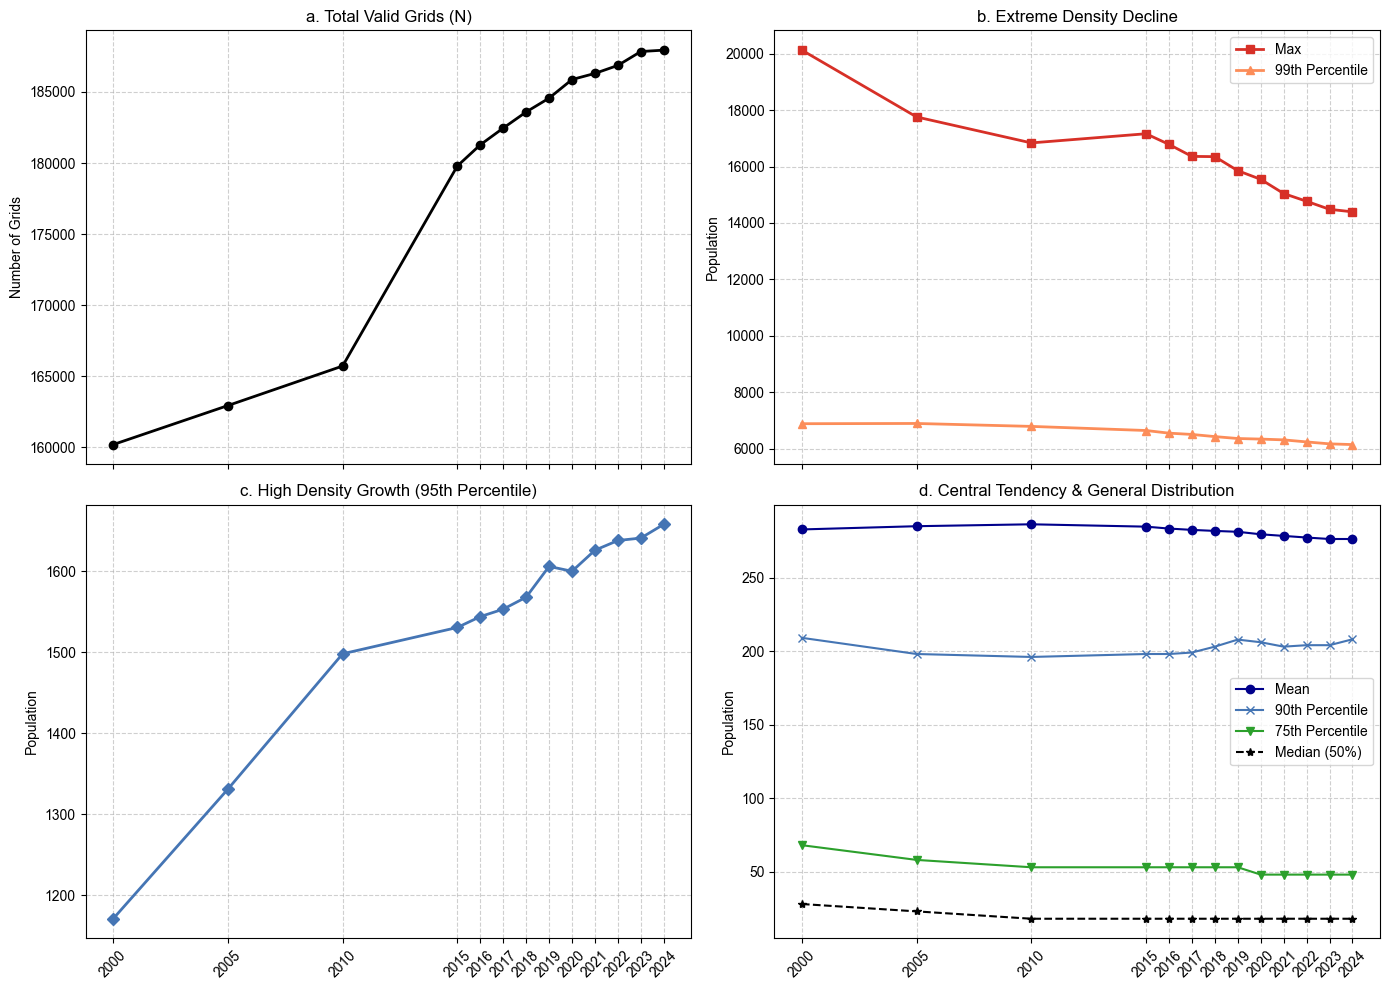

In [ ]:

# 4. 시각화 설정 (4분할 패널)
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

# 패널 A: 유효 격자 수 (공간 확장)
axes[0, 0].plot(df_stats.index, df_stats['N'], marker='o', color='black', linewidth=2)
axes[0, 0].set_title('a. Total Valid Grids (N)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Number of Grids')
axes[0, 0].grid(True, linestyle='--', alpha=0.6)

# 패널 B: 극단적 집중 완화 (Max, 99%)
axes[0, 1].plot(df_stats.index, df_stats['Max'], marker='s', color='#d73027', label='Max', linewidth=2)
axes[0, 1].plot(df_stats.index, df_stats['99%'], marker='^', color='#fc8d59', label='99th Percentile', linewidth=2)
axes[0, 1].set_title('b. Extreme Density Decline', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Population')
axes[0, 1].legend()
axes[0, 1].grid(True, linestyle='--', alpha=0.6)

# 패널 C: 상위 고밀도층 증가 (95%)
axes[1, 0].plot(df_stats.index, df_stats['95%'], marker='D', color='#4575b4', linewidth=2)
axes[1, 0].set_title('c. High Density Growth (95th Percentile)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Population')
axes[1, 0].grid(True, linestyle='--', alpha=0.6)

# 패널 D: 중심 경향 및 일반 분포 (Mean, 50%, 75%, 90%)
axes[1, 1].plot(df_stats.index, df_stats['Mean'], marker='o', color='darkblue', label='Mean')
axes[1, 1].plot(df_stats.index, df_stats['90%'], marker='x', color='#4575b4', label='90th Percentile')
axes[1, 1].plot(df_stats.index, df_stats['75%'], marker='v', color='#2ca02c', label='75th Percentile')
axes[1, 1].plot(df_stats.index, df_stats['50%'], marker='*', color='black', label='Median (50%)', linestyle='--')
axes[1, 1].set_title('d. Central Tendency & General Distribution', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Population')
axes[1, 1].legend()
axes[1, 1].grid(True, linestyle='--', alpha=0.6)

# 하단 패널(C, D)의 X축 눈금 회전 적용
for ax in axes[1, :]:
    ax.set_xticks(df_stats.index)
    ax.set_xticklabels(df_stats.index, rotation=45)

plt.tight_layout()

# 5. 고해상도 이미지 저장 (300 DPI)
output_image_path = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/Descriptive_Stats_Panel.jpg'
fig.savefig(output_image_path, dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
#@title UPI새롭게 정의해서 계산(분모: 2000년 당시 1000 이상이었던 유효격자수)
import pandas as pd

# 1. 공간 조인 완료된 최종 데이터 로드
file_path = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/Grid_centroids_Joined_Final.csv' # 실제 경로명 확인 필요
df = pd.read_csv(file_path)


In [ ]:
df.columns

Index(['fid', 'GRID_CD', 'layer', 'path', 'p2000', 'p2005', 'p2010', 'p2015',
       'p2016', 'p2017', 'p2018', 'p2019', 'p2020', 'p2021', 'p2022', 'p2023',
       'p2024', 'h2005', 'h2010', 'h2015', 'h2016', 'h2017', 'h2018', 'h2019',
       'h2020', 'h2021', 'h2022', 'h2023', 'h2024', 'fid_2', 'BASE_DATE',
       'SIGUNGU_NM', 'SIGUNGU_CD', 'SIDO_NM', 'City_name', 'n', 'distance',
       'feature_x', 'feature_y', 'nearest_x', 'nearest_y'],
      dtype='object')

In [ ]:

# 2. 새로운 분모 산출: 2000년 기준 인구 1,000명 이상인 고밀도 핵심 격자 수 추출
# p2000 컬럼명이 실제 데이터와 일치하는지 확인하십시오.
core_grids_2000 = df[df['p2000'] >= 1000].groupby('City_name').size().reset_index(name='core_grids_2000')

# 3. 분석 대상 연도 리스트 설정
years = [2005, 2010, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

# 결과 통합을 위한 데이터프레임 초기화
city_upi_revised = core_grids_2000.copy()

# 4. 연도별 천공 격자 수 및 새로운 UPI 산출
for year in years:
    h_col = f'h{year}'

    # 논리형 변수 숫자형 변환
    df[h_col] = df[h_col].replace({'True': 1, 'False': 0, True: 1, False: 0}).astype(float)

    # 연도별 천공 격자 수 합산
    hollowed_sum = df.groupby('City_name')[h_col].sum().reset_index(name=f'hollowed_{year}')

    # 병합
    city_upi_revised = pd.merge(city_upi_revised, hollowed_sum, on='City_name')

    # 수정된 UPI 산출: (해당 연도 천공 격자 수 / 2000년 핵심 격자 수) * 100
    # 분모가 0인 경우 결측치 처리 (2000년에 1000명 이상 격자가 아예 없었던 소규모 지역 방어 로직)
    city_upi_revised[f'UPI_{year}'] = (city_upi_revised[f'hollowed_{year}'] / city_upi_revised['core_grids_2000']) * 100

# 5. 소수점 둘째 자리 반올림 및 정렬 (2000년 핵심 격자 수 규모 순)
city_upi_revised = city_upi_revised.round(2)
city_upi_revised_sorted = city_upi_revised.sort_values(by='core_grids_2000', ascending=False)

# 결과 상위 5개 행 확인
print(city_upi_revised_sorted.head())


/tmp/ipykernel_524/2882898329.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[h_col] = df[h_col].replace({'True': 1, 'False': 0, True: 1, False: 0}).astype(float)
/tmp/ipykernel_524/2882898329.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[h_col] = df[h_col].replace({'True': 1, 'False': 0, True: 1, False: 0}).astype(float)
/tmp/ipykernel_524/2882898329.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.i

   City_name  core_grids_2000  hollowed_2005  UPI_2005  hollowed_2010  \
93     서울특별시             1505           29.0      1.93           33.0   
92     부산광역시              672           27.0      4.02           41.0   
90     대구광역시              499           13.0      2.61           13.0   
96     인천광역시              405            8.0      1.98           11.0   
91     대전광역시              302            6.0      1.99            7.0   

    UPI_2010  hollowed_2015  UPI_2015  hollowed_2016  UPI_2016  ...  \
93      2.19           30.0      1.99           34.0      2.26  ...   
92      6.10           41.0      6.10           42.0      6.25  ...   
90      2.61           16.0      3.21           21.0      4.21  ...   
96      2.72           12.0      2.96           14.0      3.46  ...   
91      2.32           11.0      3.64           13.0      4.30  ...   

    hollowed_2020  UPI_2020  hollowed_2021  UPI_2021  hollowed_2022  UPI_2022  \
93           36.0      2.39           44.0      2.92 

/tmp/ipykernel_524/2882898329.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[h_col] = df[h_col].replace({'True': 1, 'False': 0, True: 1, False: 0}).astype(float)


In [ ]:

# 6. 수정된 지표 저장
output_path = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/City_Level_UPI_Revised_Time_Series.csv'
city_upi_revised_sorted.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"\n수정된 기반의 도시 단위 UPI 산출 결과 저장 완료: {output_path}")


수정된 기반의 도시 단위 UPI 산출 결과 저장 완료: /content/drive/MyDrive/Urban Scaling/Grid Pop Data/City_Level_UPI_Revised_Time_Series.csv


In [ ]:
import pandas as pd

# 1. 수정된 UPI 산출 결과 로드
file_path = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/City_Level_UPI_Revised_Time_Series.csv'
df_revised_upi = pd.read_csv(file_path)

# 2. 분석 대상 연도 지정 및 UPI 컬럼 추출
years = [2005, 2010, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
upi_cols = [f'UPI_{year}' for year in years]

# 3. 연도별 수정된 UPI 기술통계량 산출
# 결측치(NaN)가 있는 경우 pandas describe()는 이를 자동으로 제외하고 연산합니다.
upi_stats_revised = df_revised_upi[upi_cols].describe().T.round(2)

# 4. 컬럼명 표준화
upi_stats_revised.columns = ['N', 'Mean', 'Std', 'Min', '25%', '50%', '75%', 'Max']

# 5. 결과 출력
print(upi_stats_revised)

              N   Mean    Std  Min    25%    50%    75%    Max
UPI_2005  160.0  12.44  16.32  0.0   1.89   6.32  16.67  100.0
UPI_2010  160.0  21.13  21.72  0.0   5.31  14.48  28.57  100.0
UPI_2015  160.0  20.58  21.00  0.0   5.36  14.07  28.78  100.0
UPI_2016  160.0  21.08  19.88  0.0   6.22  14.81  30.00  100.0
UPI_2017  160.0  22.86  20.85  0.0   7.37  16.23  33.33  100.0
UPI_2018  160.0  23.89  21.18  0.0   8.41  18.92  33.33  100.0
UPI_2019  160.0  24.85  21.96  0.0   7.68  18.84  35.62  100.0
UPI_2020  160.0  25.73  22.67  0.0   8.65  20.00  37.50  100.0
UPI_2021  160.0  28.10  24.50  0.0   9.33  22.22  40.00  100.0
UPI_2022  160.0  28.86  23.91  0.0   9.46  24.52  43.08  100.0
UPI_2023  160.0  29.31  23.66  0.0  10.50  25.00  43.75  100.0
UPI_2024  160.0  31.22  24.64  0.0  11.94  25.00  45.10  100.0


전체 유효 격자 수를 분모로 사용할 경우 발생하는 치명적인 한계와, 제안하신 새로운 분모(2000년 기준 인구 1,000명 이상 격자 수)가 갖는 학술적 타당성

1. 위험 집단(Risk Set)의 정확한 통제
천공(Hollowing)의 조작적 정의가 2000년에 1,000명 이상이었으나 특정 연도에 1,000명 미만으로 감소한 격자라면, 애초에 2000년에 1,000명 미만이었던 외곽 지역이나 저밀도 주거지는 천공이 발생할 가능성 자체가 없는 집단입니다. 분모를 2000년 기준 1,000명 이상 격자로 한정하는 것은 생존 분석 등에서 사건 발생 가능성이 있는 위험 집단(Risk Set)만을 모수로 설정하는 정밀한 통계적 접근과 일치합니다.

2. 외연적 팽창에 의한 지표 희석(Dilution) 방지
앞서 기초통계량에서 확인했듯, 한국의 도시들은 지난 24년간 유효 격자 수(N)가 지속적으로 증가하는 형태적 팽창을 겪었습니다. 전체 유효 격자를 분모로 두면, 신도시 개발 등으로 외곽의 저밀도 격자가 새롭게 편입될 때마다 분모가 커져 내부의 심각한 공동화 수치가 인위적으로 낮게 축소되는 왜곡이 발생합니다.

3. 순수 내부 쇠퇴율(Internal Decay Rate) 도출
수정된 산식은 과거 고밀도를 형성했던 핵심 도시화 구역(Urban Core) 중 정확히 몇 퍼센트(%)가 쇠퇴하여 이탈했는지를 직관적으로 보여주는 순수 내부 쇠퇴율 지표가 됩니다. 이는 타 도시와의 객관적 비교를 가능하게 하는 매우 강력한 지표입니다.

제안하신 분모 수정이 지표의 민감도를 획기적으로 높였습니다. 외연적 팽창에 의한 분모 희석 효과가 통제되자, 도시 핵심부에서 실제로 진행 중인 다공화 현상의 심각성이 명확하게 수치로 드러났습니다.

산출된 기술통계량이 지시하는 핵심적인 학술적 발견은 다음과 같습니다.

1. 비도시 지역의 통제와 모수(N) 감소
관측 대상 도시 수(N)가 161개에서 160개로 감소했습니다. 이는 2000년 당시에 인구 1,000명 이상을 기록한 고밀도 격자가 단 하나도 없었던 극소규모 지자체 1곳이 분석 모수에서 자연스럽게 배제되었음을 의미합니다. 기초적인 도시화 임계점을 넘지 못한 지역을 천공 분석 대상에서 제외하는 통계적 정합성이 확보되었습니다.

2. 공동화 지표의 희석 편향(Dilution Bias) 입증
전체 유효 격자를 분모로 삼았을 때 2024년 기준 0.56%에 불과했던 평균이, 2000년 핵심 격자를 분모로 한정하자 31.22%로 급증했습니다. 이는 과거 고밀도를 형성했던 도시 핵심 구역의 약 3분의 1이 24년 사이에 1,000명 미만으로 쇠퇴했음을 뜻합니다. 기존 지표가 외곽 지역의 신규 개발 및 팽창으로 인해 내부 쇠퇴율을 심각하게 과소평가하고 있었음을 증명하는 결과입니다.

3. 쇠퇴의 양극화와 한계 도시(Marginal City) 식별
표준편차(Std)가 2005년 16.32에서 2024년 24.64로 지속 상승하며 도시간 격차가 벌어지고 있습니다. 특히 최댓값(Max)이 100.0을 기록한 것은 2000년에 존재했던 고밀도 핵심 격자가 특정 연도에 이르러 예외 없이 1,000명 미만으로 붕괴된 한계 도시가 최소 1곳 이상 존재함을 지시합니다. 반면 최솟값(Min)은 0.0을 유지하여 내부 밀도를 온전히 방어한 도시들도 상존함을 보여줍니다.

In [ ]:
import pandas as pd

# 1. 161개 도시가 포함된 기존 데이터 로드
original_path = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/City_Level_UPI_Time_Series.csv'
df_original = pd.read_csv(original_path)

# 2. 160개 도시만 남은 수정된 데이터 로드
revised_path = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/City_Level_UPI_Revised_Time_Series.csv'
df_revised = pd.read_csv(revised_path)

# 3. 집합(Set) 연산을 통한 차집합(누락된 도시) 추출
original_cities = set(df_original['City_name'])
revised_cities = set(df_revised['City_name'])

missing_city = original_cities - revised_cities

# 4. 결과 출력
print(f"누락된 1개 도시: {list(missing_city)}")

누락된 1개 도시: ['전라남도신안군']


In [ ]:
#@title UPI 엑셀 저장
import pandas as pd

# 1. 수정된 UPI 데이터 로드
file_path = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/City_Level_UPI_Revised_Time_Series.csv'
df_revised_upi = pd.read_csv(file_path)

# 2. 고밀도 핵심부가 완전히 붕괴된 극단적 한계 도시 식별 (UPI = 100.0)
# 2024년 기준으로 UPI가 100인 도시와, 해당 도시의 2000년 핵심 격자 수(모수) 출력
collapsed_cities = df_revised_upi[df_revised_upi['UPI_2024'] == 100.0][['City_name', 'core_grids_2000', 'UPI_2024']]

print("--- 과거 핵심부가 완전히 붕괴된 한계 도시 ---")
print(collapsed_cities)
print("-" * 45)

# 3. 엑셀 파일(.xlsx)로 저장
excel_output_path = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/City_Level_UPI_Revised_Time_Series.xlsx'
df_revised_upi.to_excel(excel_output_path, index=False, engine='openpyxl')

print(f"\n엑셀 파일 저장 완료: {excel_output_path}")

--- 과거 핵심부가 완전히 붕괴된 한계 도시 ---
      City_name  core_grids_2000  UPI_2024
139     전라남도곡성군                4     100.0
143  강원특별자치도고성군                3     100.0
147     경상북도청송군                3     100.0
149  전북특별자치도진안군                3     100.0
152     경상북도영양군                2     100.0
156  전북특별자치도장수군                2     100.0
159  전북특별자치도임실군                1     100.0
---------------------------------------------

엑셀 파일 저장 완료: /content/drive/MyDrive/Urban Scaling/Grid Pop Data/City_Level_UPI_Revised_Time_Series.xlsx


In [ ]:
#@title Population vs. UPI

import pandas as pd
import numpy as np

# 1. 인구 데이터 로드 및 Long format 변환
pop_file_path = '/content/drive/MyDrive/Urban Scaling/vars/Population_3.xlsx'
df_pop = pd.read_excel(pop_file_path)

# 행정구역 컬럼을 제외하고 City_name_Kor와 숫자형 연도 컬럼만 추출
id_vars = ['City_name_Kor']
value_vars = [col for col in df_pop.columns if str(col).isdigit()]

df_pop_long = pd.melt(df_pop, id_vars=id_vars, value_vars=value_vars,
                      var_name='Year', value_name='Population')

# 병합을 위한 데이터 타입 및 컬럼명 표준화
df_pop_long['Year'] = df_pop_long['Year'].astype(int)
df_pop_long.rename(columns={'City_name_Kor': 'City_name'}, inplace=True)

# 2. 수정된 UPI 데이터 로드 및 Long format 변환
upi_file_path = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/City_Level_UPI_Revised_Time_Series.csv'
df_upi = pd.read_csv(upi_file_path)

# UPI_ 연도 형태의 컬럼만 추출
upi_cols = [col for col in df_upi.columns if col.startswith('UPI_')]
df_upi_long = pd.melt(df_upi, id_vars=['City_name'], value_vars=upi_cols,
                      var_name='Year_str', value_name='UPI')

# 문자열에서 연도만 추출하여 정수형으로 변환
df_upi_long['Year'] = df_upi_long['Year_str'].str.replace('UPI_', '').astype(int)
df_upi_long.drop(columns=['Year_str'], inplace=True)

# 3. 데이터 병합 (도시명 및 연도 기준 교집합)
df_merged = pd.merge(df_upi_long, df_pop_long, on=['City_name', 'Year'], how='inner')

# # 4. 스케일링 회귀 분석을 위한 자연로그 변환
# # 수학적 오류(log(0))를 방지하기 위해 인구와 UPI가 모두 0보다 큰 유효 관측치만 추출
# df_merged = df_merged[(df_merged['Population'] > 0) & (df_merged['UPI'] > 0)].copy()

# df_merged['log_Pop'] = np.log(df_merged['Population'])
# df_merged['log_UPI'] = np.log(df_merged['UPI'])

# # 5. 결과 정렬 및 저장
# df_merged = df_merged.sort_values(by=['City_name', 'Year']).reset_index(drop=True)

# # 결과 상위 5개 행 확인
# print(df_merged.head())

# merged_output_path = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/UPI_Population_Merged_Long.csv'
# df_merged.to_csv(merged_output_path, index=False, encoding='utf-8-sig')
# print(f"\n회귀 분석용 통합 데이터 저장 완료: {merged_output_path}")

In [ ]:
# 4. 스케일링 회귀 분석을 위한 로그 변환 (ln(x+1) 적용)
# 인구수는 0일 확률이 없으므로 일반 자연로그를 취하되, UPI는 0값을 보존하기 위해 log1p 사용
# log1p(x)는 수학적으로 ln(x + 1)과 동일하게 작동합니다.
df_merged['log_Pop'] = np.log(df_merged['Population'])
df_merged['log_UPI'] = np.log1p(df_merged['UPI'])

# 5. 결과 정렬 및 저장
df_merged = df_merged.sort_values(by=['City_name', 'Year']).reset_index(drop=True)

# 결과 상위 5개 행 확인
print(df_merged.head())

merged_output_path = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/UPI_Population_Merged_Long.csv'
df_merged.to_csv(merged_output_path, index=False, encoding='utf-8-sig')
print(f"\n회귀 분석용 통합 데이터 저장 완료: {merged_output_path}")

    City_name    UPI  Year  Population    log_Pop   log_UPI
0  강원특별자치도강릉시   3.08  2005    224391.0  12.321145  1.406097
1  강원특별자치도강릉시  13.85  2010    218503.0  12.294555  2.698000
2  강원특별자치도강릉시  13.85  2015    214560.0  12.276345  2.698000
3  강원특별자치도강릉시  13.85  2016    213846.0  12.273011  2.698000
4  강원특별자치도강릉시  16.92  2017    213952.0  12.273507  2.885917

회귀 분석용 통합 데이터 저장 완료: /content/drive/MyDrive/Urban Scaling/Grid Pop Data/UPI_Population_Merged_Long.csv


# Pathology 변수들 합치기

In [ ]:
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1. 기존 베이스 데이터 로드 (UPI + Population)
# ---------------------------------------------------------
base_file_path = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/UPI_Population_Merged_Long.csv'
df_base = pd.read_csv(base_file_path)

# ---------------------------------------------------------
# 2. 자살률 데이터 처리 (Wide -> Long -> 건수 변환)
# ---------------------------------------------------------
suicide_path = '/content/drive/MyDrive/Urban Scaling/vars/Suicide Rate per 100K pop.xlsx'
df_suicide = pd.read_excel(suicide_path)

id_vars = ['City_name_Kor']
value_vars = [col for col in df_suicide.columns if str(col).isdigit()]

df_suicide_long = pd.melt(df_suicide, id_vars=id_vars, value_vars=value_vars,
                          var_name='Year', value_name='Suicide_Rate_100k')

df_suicide_long['Year'] = df_suicide_long['Year'].astype(int)
df_suicide_long.rename(columns={'City_name_Kor': 'City_name'}, inplace=True)


In [ ]:

# ---------------------------------------------------------
# 3. 이혼 데이터 처리 (Wide -> Long -> 건수 변환)
# ---------------------------------------------------------
divorce_path = '/content/drive/MyDrive/Urban Scaling/vars/Divorce_Data.xlsx'
df_divorce = pd.read_excel(divorce_path)

id_vars_div = ['City_name_Kor']
value_vars_div = [col for col in df_divorce.columns if str(col).isdigit()]

df_divorce_long = pd.melt(df_divorce, id_vars=id_vars_div, value_vars=value_vars_div,
                          var_name='Year', value_name='Crude_Divorce_Rate_1k')

df_divorce_long['Year'] = df_divorce_long['Year'].astype(int)
df_divorce_long.rename(columns={'City_name_Kor': 'City_name'}, inplace=True)


In [ ]:

# ---------------------------------------------------------
# 4. 범죄 데이터 처리 (Total 합산 및 피벗)
# ---------------------------------------------------------
crime_path = '/content/drive/MyDrive/Urban Scaling/Crime Data/Final_Core_Crime_Panel_2015_2024.xlsx'
df_crime = pd.read_excel(crime_path)
df_crime.rename(columns={'City_name_Kor': 'City_name'}, inplace=True)

# 4-1. 연도-도시별 총 범죄 건수 산출
df_crime_total = df_crime.groupby(['Year', 'City_name'])['Crime_Count'].sum().reset_index(name='Total_Crime_Count')

# 4-2. 범죄 유형별 건수 피벗 (옵션: 더 세밀한 분석을 위함)
df_crime_pivot = df_crime.pivot_table(index=['Year', 'City_name'],
                                      columns='Crime_Type_Major',
                                      values='Crime_Count',
                                      aggfunc='sum').reset_index()

# 피벗 컬럼명 정리 (예: 'Crime_Count_폭력')
df_crime_pivot.columns = ['Year', 'City_name'] + [f'Crime_Count_{col}' for col in df_crime_pivot.columns if col not in ['Year', 'City_name']]

# 총 범죄와 유형별 범죄 병합
df_crime_final = pd.merge(df_crime_total, df_crime_pivot, on=['Year', 'City_name'], how='left')


In [ ]:

# ---------------------------------------------------------
# 5. 마스터 데이터 병합 (Base 데이터 기준 Left Join)
# ---------------------------------------------------------
# Base에 자살 데이터 병합
df_master = pd.merge(df_base, df_suicide_long, on=['City_name', 'Year'], how='left')

# Base에 이혼 데이터 병합
df_master = pd.merge(df_master, df_divorce_long, on=['City_name', 'Year'], how='left')

# Base에 범죄 데이터 병합
df_master = pd.merge(df_master, df_crime_final, on=['City_name', 'Year'], how='left')


In [ ]:

# ---------------------------------------------------------
# 6. 인구수 기반의 절댓값(Count) 파생 변수 및 로그 변수 생성
# ---------------------------------------------------------
# 자살 건수 산출: (10만명당 비율 / 100,000) * 인구수
df_master['Suicide_Count'] = (df_master['Suicide_Rate_100k'] / 100000) * df_master['Population']

# 이혼 건수 산출: (조이혼율(1천명당) / 1000) * 인구수
# 통계청 조이혼율은 통상 인구 1천명당 건수입니다.
df_master['Divorce_Count'] = (df_master['Crude_Divorce_Rate_1k'] / 1000) * df_master['Population']

# 로그 변환 (스케일링 분석용, 0값 보존을 위해 np.log1p 적용)
df_master['log_Suicide'] = np.log1p(df_master['Suicide_Count'])
df_master['log_Divorce'] = np.log1p(df_master['Divorce_Count'])
df_master['log_Total_Crime'] = np.log1p(df_master['Total_Crime_Count'])


In [ ]:
# ---------------------------------------------------------
#@title 7. 결과 저장
# ---------------------------------------------------------
master_output_path = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/Master_Pathology_Merged_Data.csv'
df_master.to_csv(master_output_path, index=False, encoding='utf-8-sig')

print(f"마스터 병합 데이터 저장 완료: {master_output_path}")
print("\n--- 마스터 데이터 컬럼 구조 ---")
print(df_master.columns.tolist())

마스터 병합 데이터 저장 완료: /content/drive/MyDrive/Urban Scaling/Grid Pop Data/Master_Pathology_Merged_Data.csv

--- 마스터 데이터 컬럼 구조 ---
['City_name', 'UPI', 'Year', 'Population', 'log_Pop', 'log_UPI', 'Suicide_Rate_100k', 'Crude_Divorce_Rate_1k', 'Total_Crime_Count', 'Crime_Count_Drug', 'Crime_Count_Economic', 'Crime_Count_Heinous', 'Crime_Count_Morality', 'Crime_Count_Theft', 'Crime_Count_Violent', 'Crime_Count_White-collar', 'Suicide_Count', 'Divorce_Count', 'log_Suicide', 'log_Divorce', 'log_Total_Crime']


In [ ]:
#@title 연도별 유효데이터 갯수 점검
import pandas as pd

# 1. 마스터 데이터 로드
master_file_path = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/Master_Pathology_Merged_Data.csv'
df_master = pd.read_csv(master_file_path)

# 2. 검증할 핵심 변수 선정
check_cols = [
    'City_name',             # 기준 (최대 160개)
    'Population',            # 총인구
    'UPI',                   # 천공 지수
    'Suicide_Rate_100k',     # 자살률
    'Crude_Divorce_Rate_1k', # 조이혼율
    'Total_Crime_Count'      # 범죄 총건수
]

# 3. 연도별 유효 데이터(Non-null) 개수 산출
# count() 함수는 결측치(NaN)를 제외한 유효한 값의 개수만 반환합니다.
data_completeness = df_master.groupby('Year')[check_cols].count()

# 4. 결과 출력 포맷 설정 및 출력
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

print("--- 연도별 핵심 변수 유효 관측치 개수 점검 ---")
print(data_completeness)

--- 연도별 핵심 변수 유효 관측치 개수 점검 ---
      City_name  Population  UPI  Suicide_Rate_100k  Crude_Divorce_Rate_1k  \
Year                                                                         
2005        160         160  160                160                    160   
2010        160         160  160                160                    160   
2015        160         160  160                160                    160   
2016        160         160  160                160                    160   
2017        160         160  160                160                    160   
2018        160         160  160                160                    160   
2019        160         160  160                160                    160   
2020        160         160  160                160                    160   
2021        160         160  160                160                    160   
2022        160         160  160                160                    160   
2023        160         160  160 

# 2000년 이후 UPI가 없는 연도의 UPI 데이터를 보간법으로 채우기

In [ ]:
import pandas as pd
import numpy as np
from functools import reduce

# =========================================================
# 1. UPI 데이터 로드 및 선형 보간 (2000~2024)
# =========================================================
upi_path = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/City_Level_UPI_Revised_Time_Series.csv'
df_upi_wide = pd.read_csv(upi_path)

# 기준 연도(2000년)의 천공 지수는 정의상 0.0
df_upi_wide['UPI_2000'] = 0.0

# Wide to Long 변환
upi_cols = [col for col in df_upi_wide.columns if col.startswith('UPI_')]
df_upi = pd.melt(df_upi_wide, id_vars=['City_name'], value_vars=upi_cols, var_name='Year', value_name='UPI')
df_upi['Year'] = df_upi['Year'].str.replace('UPI_', '').astype(int)

# 2000~2024년의 모든 연도에 대한 뼈대(Grid) 생성 및 선형 보간
cities = df_upi['City_name'].unique()
years_full = np.arange(2000, 2025)
df_base_upi = pd.MultiIndex.from_product([cities, years_full], names=['City_name', 'Year']).to_frame(index=False)

df_upi_full = pd.merge(df_base_upi, df_upi, on=['City_name', 'Year'], how='left')
df_upi_full = df_upi_full.sort_values(['City_name', 'Year'])

# 도시별(City_name)로 그룹화하여 비어있는 연도 선형 보간
df_upi_full['UPI'] = df_upi_full.groupby('City_name')['UPI'].transform(lambda x: x.interpolate(method='linear'))

# =========================================================
# 2. 개별 데이터 로드 및 Long format 변환
# =========================================================
# (1) 인구 데이터
pop_path = '/content/drive/MyDrive/Urban Scaling/vars/Population_3.xlsx'
df_pop_raw = pd.read_excel(pop_path)
df_pop = pd.melt(df_pop_raw, id_vars=['City_name_Kor'],
                 value_vars=[col for col in df_pop_raw.columns if str(col).isdigit()],
                 var_name='Year', value_name='Population')
df_pop['Year'] = df_pop['Year'].astype(int)
df_pop.rename(columns={'City_name_Kor': 'City_name'}, inplace=True)

# (2) 자살률 데이터
sui_path = '/content/drive/MyDrive/Urban Scaling/vars/Suicide Rate per 100K pop.xlsx'
df_sui_raw = pd.read_excel(sui_path)
df_sui = pd.melt(df_sui_raw, id_vars=['City_name_Kor'],
                 value_vars=[col for col in df_sui_raw.columns if str(col).isdigit()],
                 var_name='Year', value_name='Suicide_Rate_100k')
df_sui['Year'] = df_sui['Year'].astype(int)
df_sui.rename(columns={'City_name_Kor': 'City_name'}, inplace=True)

# (3) 이혼율 데이터
div_path = '/content/drive/MyDrive/Urban Scaling/vars/Divorce_Data.xlsx'
df_div_raw = pd.read_excel(div_path)
df_div = pd.melt(df_div_raw, id_vars=['City_name_Kor'],
                 value_vars=[col for col in df_div_raw.columns if str(col).isdigit()],
                 var_name='Year', value_name='Crude_Divorce_Rate_1k')
df_div['Year'] = df_div['Year'].astype(int)
df_div.rename(columns={'City_name_Kor': 'City_name'}, inplace=True)

# (4) 스트레스 인지율 데이터 (경로/파일명 확인 필요)
str_path = '/content/drive/MyDrive/Urban Scaling/vars/Stress_rate.xlsx'
try:
    df_str_raw = pd.read_excel(str_path)
    df_str = pd.melt(df_str_raw, id_vars=['City_name_Kor'],
                     value_vars=[col for col in df_str_raw.columns if str(col).isdigit()],
                     var_name='Year', value_name='Stress_Rate')
    df_str['Year'] = df_str['Year'].astype(int)
    df_str.rename(columns={'City_name_Kor': 'City_name'}, inplace=True)
except Exception as e:
    print(f"스트레스 데이터 병합 보류 (파일 확인 필요): {e}")
    df_str = pd.DataFrame(columns=['City_name', 'Year', 'Stress_Rate'])

# =========================================================
# (5). 범죄 데이터 (Panel) - 범죄 유형별 피벗 로직 적용
# =========================================================
cri_path = '/content/drive/MyDrive/Urban Scaling/Crime Data/Final_Core_Crime_Panel_2015_2024.xlsx'
df_cri = pd.read_excel(cri_path)
df_cri.columns = df_cri.columns.str.strip()

if 'City_name_Kor' in df_cri.columns:
    df_cri.rename(columns={'City_name_Kor': 'City_name'}, inplace=True)

# Crime_Type_Major 컬럼이 존재하면 피벗 수행
if 'Crime_Type_Major' in df_cri.columns:
    # 총 범죄 건수 산출
    df_crime_total = df_cri.groupby(['Year', 'City_name'])['Crime_Count'].sum().reset_index(name='Total_Crime_Count')

    # 범죄 유형별 건수 피벗
    df_crime_pivot = df_cri.pivot_table(index=['Year', 'City_name'],
                                        columns='Crime_Type_Major',
                                        values='Crime_Count',
                                        aggfunc='sum').reset_index()

    # 피벗 컬럼명 병합 문제 방지를 위한 문자열 변환 및 접두어 추가
    df_crime_pivot.columns = [str(col) for col in df_crime_pivot.columns]
    rename_dict = {col: f'Crime_Count_{col}' for col in df_crime_pivot.columns if col not in ['Year', 'City_name']}
    df_crime_pivot.rename(columns=rename_dict, inplace=True)

    # 총건수와 유형별 건수 병합
    df_cri_final = pd.merge(df_crime_total, df_crime_pivot, on=['Year', 'City_name'], how='left')
else:
    df_cri_final = df_cri.copy()
    if 'Crime_Count' in df_cri_final.columns and 'Total_Crime_Count' not in df_cri_final.columns:
        df_cri_final.rename(columns={'Crime_Count': 'Total_Crime_Count'}, inplace=True)



In [ ]:
# =========================================================
# 3. 마스터 병합 (Outer Join) 및 변수 생성
# =========================================================
# 존재하는 모든 연도의 데이터를 잃지 않기 위해 Outer Join 적용
dfs_to_merge = [df_upi_full, df_pop, df_sui, df_div, df_str, df_cri_final]
df_master = reduce(lambda left, right: pd.merge(left, right, on=['City_name', 'Year'], how='outer'), dfs_to_merge)

# 1998년 이전의 불필요한 공백 제거를 위해 분석 메인 타겟 연도로 필터링 (1998~2024)
df_master = df_master[(df_master['Year'] >= 1998) & (df_master['Year'] <= 2024)].copy()

# 파생 변수 산출 (인구 데이터가 존재하는 경우에만 연산)
df_master['Suicide_Count'] = (df_master['Suicide_Rate_100k'] / 100000) * df_master['Population']
df_master['Divorce_Count'] = (df_master['Crude_Divorce_Rate_1k'] / 1000) * df_master['Population']


# 자연로그(log) 변환 - 수학적 오류 방지를 위해 유효한 값에만 적용
df_master['log_Pop'] = np.log(df_master['Population'].replace(0, np.nan))
df_master['log_UPI'] = np.log1p(df_master['UPI'])
df_master['log_Suicide'] = np.log1p(df_master['Suicide_Count'])
df_master['log_Divorce'] = np.log1p(df_master['Divorce_Count'])

# 총 범죄 건수 및 모든 범죄 유형별 건수에 대해 일괄 로그 변환 적용
crime_cols = [col for col in df_master.columns if col.startswith('Total_Crime_Count') or col.startswith('Crime_Count_')]
for col in crime_cols:
    df_master[f'log_{col}'] = np.log1p(df_master[col])

df_master = df_master.sort_values(by=['City_name', 'Year']).reset_index(drop=True)


# =========================================================
# 4. 연도별 데이터 완성도(결측치) 점검
# =========================================================
check_cols = ['Population', 'UPI', 'Suicide_Rate_100k', 'Crude_Divorce_Rate_1k', 'Stress_Rate']
if 'Total_Crime_Count' in df_master.columns:
    check_cols.append('Total_Crime_Count')

# 실제 존재하는 컬럼만 필터링하여 점검
check_cols = [col for col in check_cols if col in df_master.columns]
data_completeness = df_master.groupby('Year')[check_cols].count()

print("--- 연도별 핵심 변수 유효 관측치 개수 점검 (1998~2024) ---")
pd.set_option('display.max_rows', None)
print(data_completeness)

# 최종 저장
master_output_path = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/Master_Interpolated_Merged_Data.csv'
df_master.to_csv(master_output_path, index=False, encoding='utf-8-sig')
print(f"\n최종 보간 및 병합 데이터 저장 완료: {master_output_path}")

--- 연도별 핵심 변수 유효 관측치 개수 점검 (1998~2024) ---
      Population  UPI  Suicide_Rate_100k  Crude_Divorce_Rate_1k  Stress_Rate  \
Year                                                                           
1998         160    0                162                      0            0   
1999         160    0                162                      0            0   
2000         160  160                162                    162            0   
2001         160  160                162                    162            0   
2002         160  160                162                    162            0   
2003         162  160                162                    162            0   
2004         162  160                162                    162            0   
2005         162  160                162                    162            0   
2006         162  160                162                    162            0   
2007         162  160                162                    162            0 

In [ ]:
#@title 누락도시 없는지 확인- 이상없음
import pandas as pd

# 1. 마스터 병합 데이터 로드
master_file_path = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/Master_Interpolated_Merged_Data.csv'
df_master = pd.read_csv(master_file_path)

# 2. 인구 데이터가 존재하는 전체 도시 집합(Set) 추출
cities_with_pop = set(df_master.dropna(subset=['Population'])['City_name'].unique())

# 3. 각 변수별 데이터가 존재하는 도시 집합(Set) 추출
cities_with_suicide = set(df_master.dropna(subset=['Suicide_Rate_100k'])['City_name'].unique())
cities_with_divorce = set(df_master.dropna(subset=['Crude_Divorce_Rate_1k'])['City_name'].unique())
cities_with_stress = set(df_master.dropna(subset=['Stress_Rate'])['City_name'].unique())

# 4. 차집합 연산을 통한 누락 도시 식별
missing_in_suicide = sorted(list(cities_with_pop - cities_with_suicide))
missing_in_divorce = sorted(list(cities_with_pop - cities_with_divorce))
missing_in_stress = sorted(list(cities_with_pop - cities_with_stress))

# 5. 결과 출력
print(f"총인구 데이터 존재 도시: {len(cities_with_pop)}개")
print("-" * 50)

print(f"1. 자살률 데이터 누락 도시 ({len(missing_in_suicide)}개):")
print(missing_in_suicide)
print("-" * 50)

print(f"2. 조이혼율 데이터 누락 도시 ({len(missing_in_divorce)}개):")
print(missing_in_divorce)
print("-" * 50)

print(f"3. 스트레스 인지율 데이터 누락 도시 ({len(missing_in_stress)}개):")
print(missing_in_stress)
print("-" * 50)

총인구 데이터 존재 도시: 162개
--------------------------------------------------
1. 자살률 데이터 누락 도시 (0개):
[]
--------------------------------------------------
2. 조이혼율 데이터 누락 도시 (0개):
[]
--------------------------------------------------
3. 스트레스 인지율 데이터 누락 도시 (2개):
['제주특별자치도서귀포시', '제주특별자치도제주시']
--------------------------------------------------


In [ ]:
import pandas as pd
import numpy as np

# 1. 기존 마스터 데이터 로드
master_file_path = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/Master_Interpolated_Merged_Data.csv'
df_master = pd.read_csv(master_file_path)

# 2. 스트레스 인지율 절대 건수 및 자연로그 변환 변수 추가
if 'Stress_Rate' in df_master.columns and 'log_Stress' not in df_master.columns:
    df_master['Stress_Count'] = (df_master['Stress_Rate'] / 100) * df_master['Population']
    df_master['log_Stress'] = np.log1p(df_master['Stress_Count'])

# 3. 업데이트된 데이터 저장 (덮어쓰기)
df_master.to_csv(master_file_path, index=False, encoding='utf-8-sig')

print(f"스트레스 변수(Stress_Count, log_Stress) 추가 및 마스터 데이터 업데이트 완료: {master_file_path}")

스트레스 변수(Stress_Count, log_Stress) 추가 및 마스터 데이터 업데이트 완료: /content/drive/MyDrive/Urban Scaling/Grid Pop Data/Master_Interpolated_Merged_Data.csv


In [ ]:
df_master.columns

Index(['City_name', 'Year', 'UPI', 'Population', 'Suicide_Rate_100k',
       'Crude_Divorce_Rate_1k', 'Stress_Rate', 'Total_Crime_Count',
       'Crime_Count_Drug', 'Crime_Count_Economic', 'Crime_Count_Heinous',
       'Crime_Count_Morality', 'Crime_Count_Theft', 'Crime_Count_Violent',
       'Crime_Count_White-collar', 'Suicide_Count', 'Divorce_Count', 'log_Pop',
       'log_UPI', 'log_Suicide', 'log_Divorce', 'log_Total_Crime_Count',
       'log_Crime_Count_Drug', 'log_Crime_Count_Economic',
       'log_Crime_Count_Heinous', 'log_Crime_Count_Morality',
       'log_Crime_Count_Theft', 'log_Crime_Count_Violent',
       'log_Crime_Count_White-collar', 'Stress_Count', 'log_Stress'],
      dtype='object')

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import linregress

# 1. 마스터 병합 데이터 로드
master_file_path = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/Master_Interpolated_Merged_Data.csv'
df_master = pd.read_csv(master_file_path)

# 2. 분석 대상 종속변수(Y) 자동 추출
# log_로 시작하는 변수 중 독립변수(log_Pop) 제외
target_vars = [col for col in df_master.columns if col.startswith('log_') and col != 'log_Pop']

scaling_results = []
years = sorted(df_master['Year'].dropna().unique())

# 3. 연도별, 변수별 횡단면 OLS 회귀 분석 수행
for year in years:
    df_year = df_master[df_master['Year'] == year]

    for log_y_col in target_vars:
        # X(인구)와 Y(분석 변수) 모두 결측치가 없는 유효 관측치만 추출
        valid_data = df_year[['log_Pop', log_y_col]].dropna()
        n_obs = len(valid_data)

        # 통계적 유의성을 확보할 수 있는 최소 표본 수(N=30) 설정
        if n_obs >= 30:
            x = valid_data['log_Pop']
            y = valid_data[log_y_col]

            # 최소제곱법(OLS) 적용
            slope, intercept, r_value, p_value, std_err = linregress(x, y)

            scaling_results.append({
                'Year': int(year),
                'Variable': log_y_col.replace('log_', ''),
                'Beta': round(slope, 4),
                'R_squared': round(r_value**2, 4),
                'P_value': round(p_value, 4),
                'N_Obs': n_obs
            })

# 4. 결과 데이터프레임 변환 및 정렬
df_results = pd.DataFrame(scaling_results)
df_results = df_results.sort_values(by=['Variable', 'Year']).reset_index(drop=True)

# 5. 결과 출력 및 저장
pd.set_option('display.max_rows', None)
print("--- 연도별 / 변수별 스케일링 지수(Beta) 회귀 분석 결과 ---")
print(df_results)

output_path = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/Master_Scaling_Regression_Results.xlsx'
df_results.to_excel(output_path, index=False)
print(f"\n회귀 분석 결과 저장 완료: {output_path}")

--- 연도별 / 변수별 스케일링 지수(Beta) 회귀 분석 결과 ---
     Year                  Variable    Beta  R_squared  P_value  N_Obs
0    2015          Crime_Count_Drug  1.0914     0.6105   0.0000     85
1    2016          Crime_Count_Drug  1.0314     0.6741   0.0000     85
2    2017          Crime_Count_Drug  0.9889     0.6291   0.0000     85
3    2018          Crime_Count_Drug  0.9700     0.7213   0.0000     85
4    2019          Crime_Count_Drug  0.9651     0.6778   0.0000     85
5    2020          Crime_Count_Drug  0.9500     0.6897   0.0000     85
6    2021          Crime_Count_Drug  0.9794     0.7011   0.0000     85
7    2022          Crime_Count_Drug  0.9601     0.7182   0.0000     85
8    2023          Crime_Count_Drug  0.9637     0.7412   0.0000     85
9    2024          Crime_Count_Drug  1.0175     0.7604   0.0000     85
10   2015      Crime_Count_Economic  1.1473     0.8644   0.0000     85
11   2016      Crime_Count_Economic  1.1796     0.8676   0.0000     85
12   2017      Crime_Count_Economic 

시계열 추세선 차트 저장 완료: /content/drive/MyDrive/Urban Scaling/Grid Pop Data/Pathology_Scaling_Trends.png


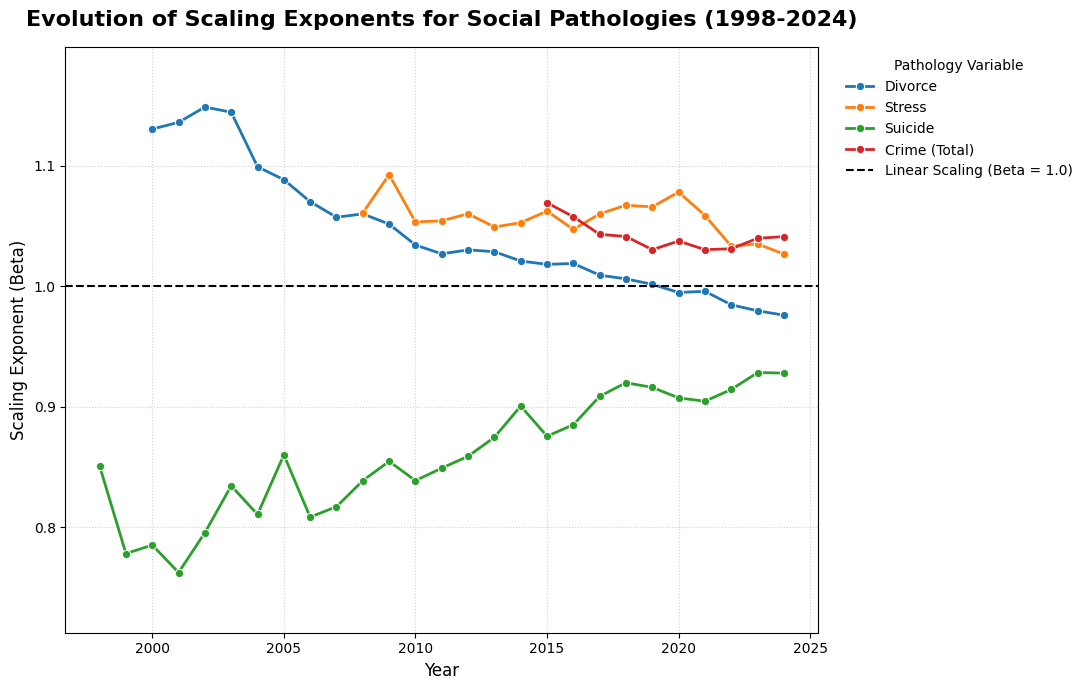

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 회귀 분석 결과 데이터 로드
file_path = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/Master_Scaling_Regression_Results.xlsx'
df_results = pd.read_excel(file_path)

# 2. 4대 사회 병리 변수 필터링
# 범죄는 총건수(Total_Crime_Count)를 대표 변수로 사용
target_vars = ['Total_Crime_Count', 'Suicide', 'Divorce', 'Stress']
df_plot = df_results[df_results['Variable'].isin(target_vars)].copy()

# 시각화를 위한 변수명 정제
var_mapping = {
    'Total_Crime_Count': 'Crime (Total)',
    'Suicide': 'Suicide',
    'Divorce': 'Divorce',
    'Stress': 'Stress'
}
df_plot['Variable_Label'] = df_plot['Variable'].map(var_mapping)

# 3. 시각화 설정
fig, ax = plt.subplots(figsize=(11, 7))

# 변수별 시계열 추세선 작도
sns.lineplot(
    data=df_plot,
    x='Year',
    y='Beta',
    hue='Variable_Label',
    marker='o',
    linewidth=2,
    markersize=6,
    ax=ax
)

# 선형 스케일링 기준선 (Beta = 1.0) 추가
ax.axhline(1.0, color='black', linestyle='--', linewidth=1.5, label='Linear Scaling (Beta = 1.0)')

# 축 및 레이블 설정
ax.set_title('Evolution of Scaling Exponents for Social Pathologies (1998-2024)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Scaling Exponent (Beta)', fontsize=12)

# Y축 범위 조정 (데이터 분포에 따라 여백 확보)
y_min = df_plot['Beta'].min() - 0.05
y_max = df_plot['Beta'].max() + 0.05
ax.set_ylim(y_min, y_max)

# 범례 위치 및 서식 최적화
ax.legend(title='Pathology Variable', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
ax.grid(True, linestyle=':', alpha=0.6)

# 레이블 잘림 방지
plt.tight_layout()

# 고해상도 이미지 저장
output_image = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/Pathology_Scaling_Trends.png'
plt.savefig(output_image, dpi=300)
print(f"시계열 추세선 차트 저장 완료: {output_image}")

4대 변수 시계열 추세선 차트 저장 완료: /content/drive/MyDrive/Urban Scaling/Grid Pop Data/Pathology_Scaling_Trends_4Vars.jpg


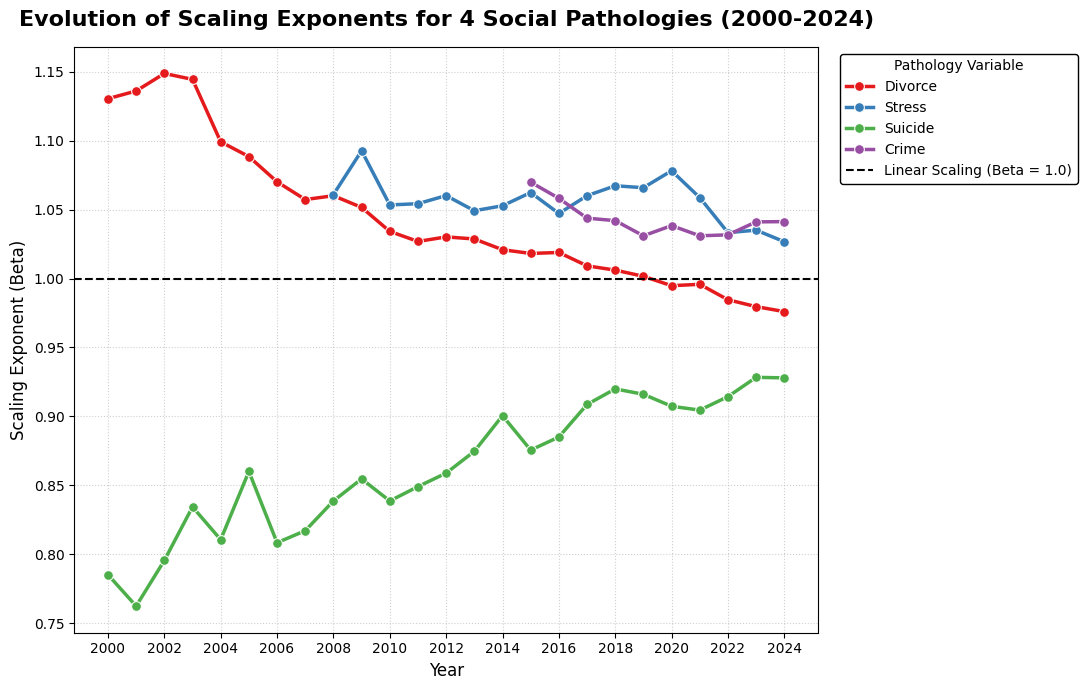

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

# 1. 마스터 데이터 로드 및 신규 범죄 변수 생성
master_path = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/Master_Interpolated_Merged_Data.csv'
df_master = pd.read_csv(master_path)

# 마약 범죄를 제외한 총 범죄 건수 산출
if 'Total_Crime_Count' in df_master.columns and 'Crime_Count_Drug' in df_master.columns:
    df_master['Crime_Count_excl_Drug'] = df_master['Total_Crime_Count'] - df_master['Crime_Count_Drug'].fillna(0)
    df_master['log_Crime_excl_Drug'] = np.log1p(df_master['Crime_Count_excl_Drug'])

# 2. 신규 범죄 변수에 대한 연도별 회귀 분석 (Beta 산출)
new_results = []
years = sorted(df_master['Year'].dropna().unique())

for year in years:
    if year < 2000 or year > 2024:
        continue
    df_year = df_master[df_master['Year'] == year]

    if 'log_Crime_excl_Drug' in df_year.columns:
        valid_data = df_year[['log_Pop', 'log_Crime_excl_Drug']].dropna()
        if len(valid_data) >= 30:
            x = valid_data['log_Pop']
            y = valid_data['log_Crime_excl_Drug']
            slope, intercept, r_value, p_value, std_err = linregress(x, y)
            new_results.append({
                'Year': int(year),
                'Variable': 'Crime_excl_Drug',
                'Beta': round(slope, 4)
            })

df_new_crime = pd.DataFrame(new_results)

# 3. 기존 회귀 분석 결과 로드 (자살, 이혼, 스트레스 추출)
results_path = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/Master_Scaling_Regression_Results.xlsx'
df_results = pd.read_excel(results_path)

# 2000~2024년 데이터 필터링 및 3대 변수 추출
df_results = df_results[(df_results['Year'] >= 2000) & (df_results['Year'] <= 2024)]
target_vars = ['Suicide', 'Divorce', 'Stress']
df_existing = df_results[df_results['Variable'].isin(target_vars)][['Year', 'Variable', 'Beta']]

# 4. 분석 결과 병합 및 변수명 라벨링
df_plot = pd.concat([df_existing, df_new_crime], ignore_index=True)

var_mapping = {
    'Crime_excl_Drug': 'Crime',
    'Suicide': 'Suicide',
    'Divorce': 'Divorce',
    'Stress': 'Stress'
}
df_plot['Variable_Label'] = df_plot['Variable'].map(var_mapping)

# 5. 시계열 추세선 시각화
fig, ax = plt.subplots(figsize=(11, 7))
palette = sns.color_palette("Set1", n_colors=4)

sns.lineplot(
    data=df_plot,
    x='Year',
    y='Beta',
    hue='Variable_Label',
    marker='o',
    linewidth=2.5,
    markersize=7,
    palette=palette,
    ax=ax
)

# 선형 스케일링 기준선 (Beta = 1.0)
ax.axhline(1.0, color='black', linestyle='--', linewidth=1.5, label='Linear Scaling (Beta = 1.0)')

# 축 및 레이블 서식
ax.set_title('Evolution of Scaling Exponents for 4 Social Pathologies (2000-2024)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Scaling Exponent (Beta)', fontsize=12)
ax.set_xticks(range(2000, 2025, 2))

# 범례 최적화
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels, title='Pathology Variable', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, edgecolor='black', framealpha=1.0)
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()

# 그래프 저장
output_image = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/Pathology_Scaling_Trends_4Vars.jpg'
plt.savefig(output_image, dpi=300)
print(f"4대 변수 시계열 추세선 차트 저장 완료: {output_image}")

In [ ]:
#@title Pathology SAMI 계산
import pandas as pd
import numpy as np
from scipy.stats import linregress

# 1. 마스터 데이터 로드
master_path = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/Master_Interpolated_Merged_Data.csv'
df_master = pd.read_csv(master_path)

# 마약 제외 범죄 파생 변수 확인 및 생성 (이전 시각화 단계에서 파일에 미저장되었을 경우 대비)
if 'Crime_Count_excl_Drug' not in df_master.columns and 'Total_Crime_Count' in df_master.columns:
    df_master['Crime_Count_excl_Drug'] = df_master['Total_Crime_Count'] - df_master['Crime_Count_Drug'].fillna(0)
    df_master['log_Crime_excl_Drug'] = np.log1p(df_master['Crime_Count_excl_Drug'])

# 2. SAMI 산출 대상 병리 변수 목록
# Key: 원본 로그 변수명, Value: 생성할 SAMI 컬럼명
target_vars = {
    'log_Crime_excl_Drug': 'SAMI_Crime',
    'log_Suicide': 'SAMI_Suicide',
    'log_Divorce': 'SAMI_Divorce',
    'log_Stress': 'SAMI_Stress'
}

# SAMI 값을 저장할 빈 컬럼 초기화
for sami_col in target_vars.values():
    df_master[sami_col] = np.nan

years = sorted(df_master['Year'].dropna().unique())

# 3. 연도별, 변수별 회귀분석 및 SAMI(잔차) 계산
for year in years:
    idx_year = df_master['Year'] == year
    df_year = df_master[idx_year]

    for log_y, sami_col in target_vars.items():
        if log_y not in df_master.columns:
            continue

        # 유효 데이터 필터링 (X와 Y 모두 결측치가 없는 인덱스 추출)
        valid_idx = df_year[['log_Pop', log_y]].dropna().index

        if len(valid_idx) >= 30:
            x = df_master.loc[valid_idx, 'log_Pop']
            y = df_master.loc[valid_idx, log_y]

            # OLS 회귀 적합 (Beta 및 Intercept 도출)
            slope, intercept, r_value, p_value, std_err = linregress(x, y)

            # 예측값(Expected) 및 SAMI(Residual) 계산
            # SAMI = Actual - Expected
            expected_y = slope * x + intercept
            sami_values = y - expected_y

            # 원본 데이터프레임의 해당 위치에 SAMI 값 매핑
            df_master.loc[valid_idx, sami_col] = sami_values

# 4. SAMI가 추가된 새로운 마스터 데이터 저장
output_path = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/Master_SAMI_Calculated.csv'
df_master.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"4대 병리 변수의 SAMI 산출 및 저장 완료: {output_path}")

4대 병리 변수의 SAMI 산출 및 저장 완료: /content/drive/MyDrive/Urban Scaling/Grid Pop Data/Master_SAMI_Calculated.csv


SAMI 값이 양수(+)이면 해당 도시는 인구 규모 대비 병리 현상이 극심한 것이고, 음수(-)이면 우수한 방어력을 갖춘 것을 의미

#

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import linregress

# 1. 마스터 데이터 로드
master_path = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/Master_SAMI_Calculated.csv'
df_master = pd.read_csv(master_path)

# 2. 회복탄력성(Resilience) 변수 로드 및 Long format 변환 함수
def melt_resilience_data(file_path, value_name):
    df = pd.read_excel(file_path)
    df_long = pd.melt(
        df,
        id_vars=['City_name_Kor'],
        value_vars=[col for col in df.columns if str(col).isdigit()],
        var_name='Year',
        value_name=value_name
    )
    df_long['Year'] = df_long['Year'].astype(int)
    df_long.rename(columns={'City_name_Kor': 'City_name'}, inplace=True)
    # [수정] 불러올 때부터 숫자로 변환하여 타입 에러 방지
    df_long[value_name] = pd.to_numeric(df_long[value_name], errors='coerce')
    return df_long

# (1) 의사 수: 새로운 절대 건수 데이터 경로 적용
doc_abs_path = '/content/drive/MyDrive/Urban Scaling/vars/Resilience Infrastructure vars/도시내의료기관_종사_의사수_정리완료.xlsx'
df_doc = melt_resilience_data(doc_abs_path, 'Doctor_Count')

# (2) 사회복지시설 수
soc_path = '/content/drive/MyDrive/Urban Scaling/vars/Resilience Infrastructure vars/사회복지시설수_정리완료.xlsx'
df_soc = melt_resilience_data(soc_path, 'Social_Welfare_Count')

# (3) 노인여가복지시설 수
sen_path = '/content/drive/MyDrive/Urban Scaling/vars/Resilience Infrastructure vars/노인여가복지시설수_정리완료.xlsx'
df_sen = melt_resilience_data(sen_path, 'Senior_Welfare_Count')

# 3. 마스터 데이터에 병합 (Left Join)
df_master = pd.merge(df_master, df_doc, on=['City_name', 'Year'], how='left')
df_master = pd.merge(df_master, df_soc, on=['City_name', 'Year'], how='left')
df_master = pd.merge(df_master, df_sen, on=['City_name', 'Year'], how='left')

# 4. 로그 변환 (역산 로직 제거)
# 인구 데이터 숫자 변환
df_master['Population'] = pd.to_numeric(df_master['Population'], errors='coerce')

# 이미 절대 건수(Doctor_Count)이므로 바로 로그 변환 적용
df_master['log_Doctor'] = np.log1p(df_master['Doctor_Count'])
df_master['log_Social_Welfare'] = np.log1p(df_master['Social_Welfare_Count'])
df_master['log_Senior_Welfare'] = np.log1p(df_master['Senior_Welfare_Count'])

# 5. Resilience 변수들의 연도별 Beta 및 SAMI 산출
resilience_vars = {
    'log_Doctor': 'SAMI_Doctor',
    'log_Social_Welfare': 'SAMI_Social_Welfare',
    'log_Senior_Welfare': 'SAMI_Senior_Welfare'
}

# SAMI 컬럼 초기화
for sami_col in resilience_vars.values():
    df_master[sami_col] = np.nan

years = sorted(df_master['Year'].dropna().unique())
resilience_results = []

for year in years:
    idx_year = df_master['Year'] == year
    df_year = df_master[idx_year]

    for log_y, sami_col in resilience_vars.items():
        if log_y not in df_master.columns:
            continue

        valid_idx = df_year[['log_Pop', log_y]].dropna().index
        if len(valid_idx) >= 30:
            x = df_master.loc[valid_idx, 'log_Pop']
            y = df_master.loc[valid_idx, log_y]

            slope, intercept, r_value, p_value, std_err = linregress(x, y)

            # Beta 기록
            resilience_results.append({
                'Year': int(year),
                'Variable': log_y.replace('log_', ''),
                'Beta': round(slope, 4)
            })

            # SAMI (Residual) 산출
            expected_y = slope * x + intercept
            df_master.loc[valid_idx, sami_col] = y - expected_y

# 6. 상관관계 분석 (SAMI 간 교차 분석)
pathology_samis = ['SAMI_Crime', 'SAMI_Suicide', 'SAMI_Divorce', 'SAMI_Stress']
resilience_samis = ['SAMI_Doctor', 'SAMI_Social_Welfare', 'SAMI_Senior_Welfare']

valid_pathology = [col for col in pathology_samis if col in df_master.columns]
valid_resilience = [col for col in resilience_samis if col in df_master.columns]

if valid_pathology and valid_resilience:
    corr_matrix = df_master[valid_pathology + valid_resilience].corr()
    target_corr = corr_matrix.loc[valid_pathology, valid_resilience]

    print("--- 최종 SAMI 간 상관계수 (Pathology vs Resilience) ---")
    pd.set_option('display.float_format', '{:.4f}'.format)
    print(target_corr)
    print("-" * 55)

# 7. 최종 데이터 저장
final_output_path = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/Master_SAMI_Final_Integrated.csv'
df_master.to_csv(final_output_path, index=False, encoding='utf-8-sig')

print(f"\n최종 SAMI 통합 데이터 저장 완료: {final_output_path}")

--- 최종 SAMI 간 상관계수 (Pathology vs Resilience) ---
              SAMI_Doctor  SAMI_Social_Welfare  SAMI_Senior_Welfare
SAMI_Crime         0.6974               0.3575               0.2141
SAMI_Suicide      -0.0432               0.2023               0.2254
SAMI_Divorce      -0.1755               0.1349              -0.2236
SAMI_Stress       -0.0515               0.1203              -0.1786
-------------------------------------------------------

최종 SAMI 통합 데이터 저장 완료: /content/drive/MyDrive/Urban Scaling/Grid Pop Data/Master_SAMI_Final_Integrated.csv


(1) 상관계수 유의성(p-value) 산출, (2) 유의성 표시가 포함된 열지표(Heatmap) 시각화, (3) 아웃라이어(Outlier) 식별을 위한 산점도 코드

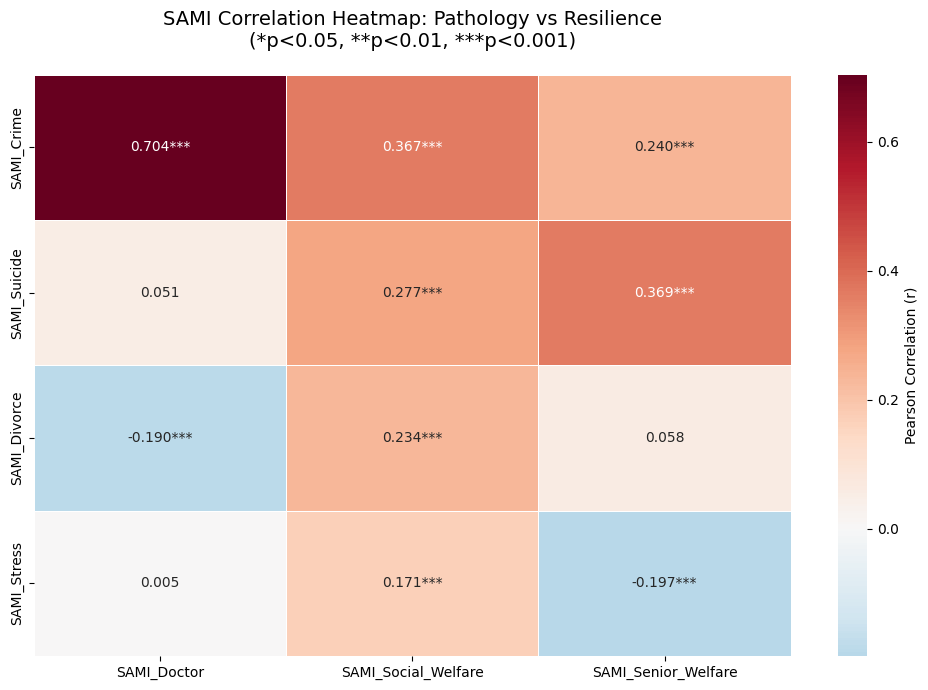

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# 1. 통합 SAMI 데이터 로드
file_path = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/Master_SAMI_Final_Integrated.csv'
df = pd.read_csv(file_path)

# 분석 대상 변수 설정
pathology_samis = ['SAMI_Crime', 'SAMI_Suicide', 'SAMI_Divorce', 'SAMI_Stress']
resilience_samis = ['SAMI_Doctor', 'SAMI_Social_Welfare', 'SAMI_Senior_Welfare']

# 결측치 제외 (상관분석용)
df_clean = df.dropna(subset=pathology_samis + resilience_samis)

# 2. 상관계수 및 p-value 행렬 산출
corr_matrix = pd.DataFrame(index=pathology_samis, columns=resilience_samis)
p_matrix = pd.DataFrame(index=pathology_samis, columns=resilience_samis)

for p_var in pathology_samis:
    for r_var in resilience_samis:
        r_val, p_val = pearsonr(df_clean[p_var], df_clean[r_var])
        corr_matrix.loc[p_var, r_var] = r_val
        p_matrix.loc[p_var, r_var] = p_val

# 유의성 표기(Significance stars)를 위한 어노테이션 행렬 생성
annot_matrix = corr_matrix.copy().astype(str)
for p_var in pathology_samis:
    for r_var in resilience_samis:
        val = corr_matrix.loc[p_var, r_var]
        p = p_matrix.loc[p_var, r_var]
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        annot_matrix.loc[p_var, r_var] = f"{val:.3f}{sig}"

# 3. 열지표(Heatmap) 시각화
plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix.astype(float), annot=annot_matrix, fmt="", cmap='RdBu_r', center=0,
            linewidths=0.5, cbar_kws={'label': 'Pearson Correlation (r)'})
plt.title('SAMI Correlation Heatmap: Pathology vs Resilience\n(*p<0.05, **p<0.01, ***p<0.001)', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Urban Scaling/Grid Pop Data/SAMI_Correlation_Heatmap.png', dpi=300)


In [ ]:
# 2024년 데이터 개수 확인
df_2024_check = df[df['Year'] == 2024]
print("--- 2024년 변수별 유효 데이터 개수 ---")
print(df_2024_check[['SAMI_Divorce', 'SAMI_Stress', 'SAMI_Senior_Welfare']].notnull().sum())

--- 2024년 변수별 유효 데이터 개수 ---
SAMI_Divorce           162
SAMI_Stress            160
SAMI_Senior_Welfare    161
dtype: int64


In [ ]:
#@title 영문 도시명 변수 merge & save

import pandas as pd

# 1. 기존 통합 SAMI 데이터 로드
master_path = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/Master_SAMI_Final_Integrated.csv'
df_master = pd.read_csv(master_path)

# 2. 영문 이름 매핑 데이터 로드
mapping_path = '/content/drive/MyDrive/Urban Scaling/Cityname_Korean_English.xlsx'
df_mapping = pd.read_excel(mapping_path)

# 3. 데이터 병합 (City_name 기준으로 영문 이름 추가)
# 매핑 파일의 'City_name_Kor'와 마스터의 'City_name'을 매칭
df_final = pd.merge(
    df_master,
    df_mapping[['City_name_Kor', 'City_name_Eng']],
    left_on='City_name',
    right_on='City_name_Kor',
    how='left'
)

# 중복된 기준 컬럼(City_name_Kor) 제거
df_final = df_final.drop(columns=['City_name_Kor'])

# 4. 최종 데이터셋 저장
# 이후 분석에서 혼동되지 않도록 'English_Integrated'라는 명칭을 붙여 저장합니다.
save_path = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/Master_SAMI_Final_English_Integrated.csv'
df_final.to_csv(save_path, index=False, encoding='utf-8-sig')

print(f"영문 도시명이 포함된 최종 통합 데이터셋 저장 완료: {save_path}")
print(f"총 행 수: {len(df_final)}, 컬럼 수: {len(df_final.columns)}")

영문 도시명이 포함된 최종 통합 데이터셋 저장 완료: /content/drive/MyDrive/Urban Scaling/Grid Pop Data/Master_SAMI_Final_English_Integrated.csv
총 행 수: 4374, 컬럼 수: 47


In [ ]:
df_final.columns

Index(['City_name', 'Year', 'UPI', 'Population', 'Suicide_Rate_100k',
       'Crude_Divorce_Rate_1k', 'Stress_Rate', 'Total_Crime_Count',
       'Crime_Count_Drug', 'Crime_Count_Economic', 'Crime_Count_Heinous',
       'Crime_Count_Morality', 'Crime_Count_Theft', 'Crime_Count_Violent',
       'Crime_Count_White-collar', 'Suicide_Count', 'Divorce_Count', 'log_Pop',
       'log_UPI', 'log_Suicide', 'log_Divorce', 'log_Total_Crime_Count',
       'log_Crime_Count_Drug', 'log_Crime_Count_Economic',
       'log_Crime_Count_Heinous', 'log_Crime_Count_Morality',
       'log_Crime_Count_Theft', 'log_Crime_Count_Violent',
       'log_Crime_Count_White-collar', 'Stress_Count', 'log_Stress',
       'Crime_Count_excl_Drug', 'log_Crime_excl_Drug', 'SAMI_Crime',
       'SAMI_Suicide', 'SAMI_Divorce', 'SAMI_Stress', 'Doctor_Count',
       'Social_Welfare_Count', 'Senior_Welfare_Count', 'log_Doctor',
       'log_Social_Welfare', 'log_Senior_Welfare', 'SAMI_Doctor',
       'SAMI_Social_Welfare', 'SAMI_S

In [ ]:
# 연도별로 City_name의 유효 개수를 카운트
yearly_city_counts = df_final.groupby('Year')['City_name'].nunique()

print("--- 연도별 고유 도시 수 확인 ---")
print(yearly_city_counts)

# 전체 기간 중 도시 수가 가장 적거나 많은 연도 확인
print(f"\n최소 도시 수: {yearly_city_counts.min()}개 ({yearly_city_counts.idxmin()}년)")
print(f"최대 도시 수: {yearly_city_counts.max()}개 ({yearly_city_counts.idxmax()}년)")

--- 연도별 고유 도시 수 확인 ---
Year
1998    162
1999    162
2000    162
2001    162
2002    162
2003    162
2004    162
2005    162
2006    162
2007    162
2008    162
2009    162
2010    162
2011    162
2012    162
2013    162
2014    162
2015    162
2016    162
2017    162
2018    162
2019    162
2020    162
2021    162
2022    162
2023    162
2024    162
Name: City_name, dtype: int64

최소 도시 수: 162개 (1998년)
최대 도시 수: 162개 (1998년)


In [ ]:
# 현재 연결
df_master = df_final

# # 나중에 다시 분석할 때
# import pandas as pd
# load_path = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/Master_SAMI_Final_English_Integrated.csv'
# df_master = pd.read_csv(load_path)

# # 바로 분석 시작!

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# 3. 분석 대상 리스트 설정
pathology_vars = ['SAMI_Crime', 'SAMI_Suicide', 'SAMI_Divorce', 'SAMI_Stress']
resilience_vars = ['SAMI_Doctor', 'SAMI_Social_Welfare'] # 이번에 추가로 확인할 변수들

def plot_sami_grid(df_data, target_year):
    df_year = df_data[df_data['Year'] == target_year].copy()

    for r_var in resilience_vars:
        for p_var in pathology_vars:
            df_plot = df_year.dropna(subset=[r_var, p_var])
            if len(df_plot) < 10: continue

            # 통계치 계산
            r_val, p_val = pearsonr(df_plot[r_var], df_plot[p_var])
            sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "(N.S.)"

            plt.figure(figsize=(10, 7))

            # 산점도 및 회귀선
            sns.regplot(data=df_plot, x=r_var, y=p_var,
                        scatter_kws={'alpha':0.4, 's':50, 'color':'#2980b9'},
                        line_kws={'color':'#c0392b', 'ls':'--'})

            # 아웃라이어 라벨링 (1.5 표준편차 기준)
            x_m, x_s = df_plot[r_var].mean(), df_plot[r_var].std()
            y_m, y_s = df_plot[p_var].mean(), df_plot[p_var].std()

            for _, row in df_plot.iterrows():
                label = row['City_name_Eng'] if pd.notnull(row['City_name_Eng']) else row['City_name']
                if abs(row[r_var] - x_m) > 1.5 * x_s or abs(row[p_var] - y_m) > 1.5 * y_s:
                    plt.text(row[r_var], row[p_var], label, fontsize=9, fontweight='bold')

            # 서식 설정
            plt.axhline(0, color='black', lw=0.8, alpha=0.3)
            plt.axvline(0, color='black', lw=0.8, alpha=0.3)
            plt.title(f'{p_var} vs {r_var} ({target_year})\nPearson $r$ = {r_val:.3f}, $p$ = {p_val:.4f} {sig}',
                      fontsize=13, pad=15)
            plt.xlabel(f'Resilience: {r_var}')
            plt.ylabel(f'Pathology: {p_var}')
            plt.grid(True, linestyle=':', alpha=0.4)

            # 파일명 자동 생성 및 저장
            filename = f"SAMI_Scatter_{r_var}_{p_var}_{target_year}.png"
            plt.tight_layout()
            plt.savefig(f'/content/drive/MyDrive/Urban Scaling/Grid Pop Data/{filename}', dpi=300)
            plt.close() # 메모리 효율을 위해 닫기
            print(f"저장 완료: {filename}")

# 4. 2024년 데이터로 일괄 생성
plot_sami_grid(df_master, 2024)

저장 완료: SAMI_Scatter_SAMI_Doctor_SAMI_Crime_2024.png
저장 완료: SAMI_Scatter_SAMI_Doctor_SAMI_Suicide_2024.png
저장 완료: SAMI_Scatter_SAMI_Doctor_SAMI_Divorce_2024.png
저장 완료: SAMI_Scatter_SAMI_Doctor_SAMI_Stress_2024.png


In [ ]:
df_final.columns

Index(['City_name', 'Year', 'UPI', 'Population', 'Suicide_Rate_100k',
       'Crude_Divorce_Rate_1k', 'Stress_Rate', 'Total_Crime_Count',
       'Crime_Count_Drug', 'Crime_Count_Economic', 'Crime_Count_Heinous',
       'Crime_Count_Morality', 'Crime_Count_Theft', 'Crime_Count_Violent',
       'Crime_Count_White-collar', 'Suicide_Count', 'Divorce_Count', 'log_Pop',
       'log_UPI', 'log_Suicide', 'log_Divorce', 'log_Total_Crime_Count',
       'log_Crime_Count_Drug', 'log_Crime_Count_Economic',
       'log_Crime_Count_Heinous', 'log_Crime_Count_Morality',
       'log_Crime_Count_Theft', 'log_Crime_Count_Violent',
       'log_Crime_Count_White-collar', 'Stress_Count', 'log_Stress',
       'Crime_Count_excl_Drug', 'log_Crime_excl_Drug', 'SAMI_Crime',
       'SAMI_Suicide', 'SAMI_Divorce', 'SAMI_Stress', 'Doctor_Count',
       'Social_Welfare_Count', 'Senior_Welfare_Count', 'log_Doctor',
       'log_Social_Welfare', 'log_Senior_Welfare', 'SAMI_Doctor',
       'SAMI_Social_Welfare', 'SAMI_S

In [ ]:
#@title Shriking City 정의
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# 1. 데이터 로드
load_path = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/Master_SAMI_Final_English_Integrated.csv'
df_162 = pd.read_csv(load_path)

# 2. 도시별 피크 인구(Max) 산출
# 모든 연도를 통틀어 도시별 가장 높았던 인구수를 찾습니다.
peak_pop = df_162.groupby('City_name')['Population'].max().reset_index()
peak_pop.columns = ['City_name', 'Peak_Population']

# 3. 2024년 데이터와 결합
df_2024 = df_162[df_162['Year'] == 2024].copy()
df_analysis = pd.merge(df_2024, peak_pop, on='City_name', how='left')

# 4. 피크 대비 유지율(Retention Rate) 계산
# 1.0이면 피크 유지, 0.9이면 피크 대비 10% 감소
df_analysis['Peak_Ratio'] = df_analysis['Population'] / df_analysis['Peak_Population']

# 5. Shrinking City 정의 (임계값 설정: 예 - 10% 이상 감소 시)
# 학술적으로는 0.90(10% 감소) 또는 0.95(5% 감소)를 주로 사용합니다.
threshold = 0.90
df_analysis['Status'] = np.where(df_analysis['Peak_Ratio'] < threshold, 'Shrinking', 'Growing/Stable')

print(f"--- 분류 결과 (Threshold: {threshold}) ---")
print(df_analysis['Status'].value_counts())

# 6. 가설 검증: T-test 수행
pathology_vars = ['SAMI_Crime', 'SAMI_Suicide', 'SAMI_Divorce', 'SAMI_Stress']
resilience_vars = ['SAMI_Doctor', 'SAMI_Social_Welfare', 'SAMI_Senior_Welfare']
all_vars = pathology_vars + resilience_vars

results = []
for var in all_vars:
    group_s = df_analysis[df_analysis['Status'] == 'Shrinking'][var].dropna()
    group_g = df_analysis[df_analysis['Status'] == 'Growing/Stable'][var].dropna()

    t_stat, p_val = ttest_ind(group_s, group_g)
    results.append({
        'Variable': var,
        'Shrinking_Mean': group_s.mean(),
        'Growing_Mean': group_g.mean(),
        'Diff': group_s.mean() - group_g.mean(),
        'p-value': p_val,
        'Significant': p_val < 0.05
    })

df_res = pd.DataFrame(results)
print("\n--- 가설 검증 결과 (Shrinking vs Growing) ---")
display(df_res)

--- 분류 결과 (Threshold: 0.9) ---
Status
Shrinking         99
Growing/Stable    63
Name: count, dtype: int64

--- 가설 검증 결과 (Shrinking vs Growing) ---


/usr/local/lib/python3.12/dist-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


,Variable,Shrinking_Mean,Growing_Mean,Diff,p-value,Significant
0,SAMI_Crime,0.0059,-0.0036,0.0095,0.9031,False
1,SAMI_Suicide,0.0263,-0.0414,0.0677,0.1299,False
2,SAMI_Divorce,-0.0117,0.0183,-0.0300,0.3359,False
3,SAMI_Stress,0.0007,-0.0011,0.0018,0.9424,False
4,SAMI_Doctor,0.0379,-0.0596,0.0975,0.0681,False
5,SAMI_Social_Welfare,NaN,NaN,NaN,NaN,False
6,SAMI_Senior_Welfare,0.0879,-0.1367,0.2245,0.0134,True


In [ ]:
df_final.columns

Index(['City_name', 'Year', 'UPI', 'Population', 'Suicide_Rate_100k',
       'Crude_Divorce_Rate_1k', 'Stress_Rate', 'Total_Crime_Count',
       'Crime_Count_Drug', 'Crime_Count_Economic', 'Crime_Count_Heinous',
       'Crime_Count_Morality', 'Crime_Count_Theft', 'Crime_Count_Violent',
       'Crime_Count_White-collar', 'Suicide_Count', 'Divorce_Count', 'log_Pop',
       'log_UPI', 'log_Suicide', 'log_Divorce', 'log_Total_Crime_Count',
       'log_Crime_Count_Drug', 'log_Crime_Count_Economic',
       'log_Crime_Count_Heinous', 'log_Crime_Count_Morality',
       'log_Crime_Count_Theft', 'log_Crime_Count_Violent',
       'log_Crime_Count_White-collar', 'Stress_Count', 'log_Stress',
       'Crime_Count_excl_Drug', 'log_Crime_excl_Drug', 'SAMI_Crime',
       'SAMI_Suicide', 'SAMI_Divorce', 'SAMI_Stress', 'Doctor_Count',
       'Social_Welfare_Count', 'Senior_Welfare_Count', 'log_Doctor',
       'log_Social_Welfare', 'log_Senior_Welfare', 'SAMI_Doctor',
       'SAMI_Social_Welfare', 'SAMI_S

In [ ]:
# 2024년 변수별 유효 데이터 개수 확인
check_null = df_analysis[['SAMI_Doctor', 'SAMI_Social_Welfare', 'SAMI_Senior_Welfare']].notnull().sum()
print("--- 2024년 변수별 유효 데이터(Non-Null) 개수 ---")
print(check_null)

# 만약 SAMI_Social_Welfare가 0이라면, 원본 지표인 Social_Welfare_Count가 있는지 확인
check_raw = df_analysis['Social_Welfare_Count'].notnull().sum()
print(f"\n원본 Social_Welfare_Count 개수: {check_raw}")

--- 2024년 변수별 유효 데이터(Non-Null) 개수 ---
SAMI_Doctor            162
SAMI_Social_Welfare      0
SAMI_Senior_Welfare    161
dtype: int64

원본 Social_Welfare_Count 개수: 0


In [ ]:
# 연도별 Social_Welfare_Count의 유효 데이터 개수 확인
sw_completeness = df_162.groupby('Year')['Social_Welfare_Count'].count()

print("--- 연도별 사회복지시설 데이터 유효 개수 ---")
print(sw_completeness.tail(5)) # 최근 5개년 확인

# 가장 데이터가 많은(160개 이상) 최근 연도 자동 추출
best_year = sw_completeness[sw_completeness >= 160].index.max()
print(f"\n최적의 분석 연도: {best_year}년")

--- 연도별 사회복지시설 데이터 유효 개수 ---
Year
2020    162
2021    162
2022    162
2023    162
2024      0
Name: Social_Welfare_Count, dtype: int64

최적의 분석 연도: 2023년


In [ ]:
# 1. 분석 연도 설정 (위에서 확인한 best_year 사용)
analysis_year = int(best_year)

# 2. 분석 연도 데이터 추출
df_selected = df_162[df_162['Year'] == analysis_year].copy()

# 3. 인구 변화율 계산 (피크 인구 대비)
peak_pop = df_162.groupby('City_name')['Population'].max().reset_index()
peak_pop.columns = ['City_name', 'Peak_Population']

df_final_analysis = pd.merge(df_selected, peak_pop, on='City_name', how='left')
df_final_analysis['Peak_Ratio'] = df_final_analysis['Population'] / df_final_analysis['Peak_Population']

# 4. Shrinking City 재분류 (Threshold: 0.90)
df_final_analysis['Status'] = np.where(df_final_analysis['Peak_Ratio'] < 0.90, 'Shrinking', 'Growing/Stable')

# 5. T-test 재실행 (모든 SAMI 변수 포함)
results = []
for var in all_vars:
    # 해당 연도에 SAMI 값이 있는 것만 필터링
    valid_data = df_final_analysis.dropna(subset=[var])
    group_s = valid_data[valid_data['Status'] == 'Shrinking'][var]
    group_g = valid_data[valid_data['Status'] == 'Growing/Stable'][var]

    if len(group_s) > 1 and len(group_g) > 1:
        t_stat, p_val = ttest_ind(group_s, group_g)
        results.append({
            'Variable': var,
            'Shrinking_Mean': group_s.mean(),
            'Growing_Mean': group_g.mean(),
            'Diff(S-G)': group_s.mean() - group_g.mean(),
            'p-value': p_val,
            'Significant': p_val < 0.05
        })

df_res_final = pd.DataFrame(results)
print(f"--- {analysis_year}년 기준 가설 검증 결과 ---")
display(df_res_final)

--- 2023년 기준 가설 검증 결과 ---


,Variable,Shrinking_Mean,Growing_Mean,Diff(S-G),p-value,Significant
0,SAMI_Crime,-0.0144,0.0071,-0.0215,0.7869,False
1,SAMI_Suicide,0.0107,-0.0152,0.0258,0.5131,False
2,SAMI_Divorce,-0.0124,0.0175,-0.0299,0.2876,False
3,SAMI_Stress,-0.0077,0.0112,-0.0189,0.3885,False
4,SAMI_Doctor,0.0410,-0.0582,0.0992,0.0728,False
5,SAMI_Social_Welfare,0.0124,-0.0176,0.0300,0.6730,False
6,SAMI_Senior_Welfare,0.1252,-0.1756,0.3008,0.0008,True


인구 감소 도시($Shrinking$)와 성장 도시($Growing$) 그룹별로 회복탄력성($Resilience$) 지표가 사회 병리($Pathology$) 현상을 억제하는 상관관계의 강도를 비교 분석하겠습니다.박사님의 가설을 검증하기 위해, 각 그룹 내에서 **회복탄력성 지표와 병리 지표 간의 상관계수($r$)**를 각각 산출하여 비교하는 코드를 작성했습니다. 이 분석을 통해 "남겨진 인프라가 인구 감소 도시에서 실제로 방어 기제 역할을 하는지"를 정밀하게 확인할 수 있습니다.

--- [2023년] 그룹별 SAMI 상관관계 비교 (N_Shrinking=95, N_Growing=67) ---

[Shrinking Cities Group]
             SAMI_Doctor SAMI_Social_Welfare SAMI_Senior_Welfare
SAMI_Crime         0.269               0.075              -0.232
SAMI_Suicide      -0.087               0.081              -0.064
SAMI_Divorce      -0.048               0.140              -0.144
SAMI_Stress        0.176              0.207*              -0.043

[Growing/Stable Cities Group]
             SAMI_Doctor SAMI_Social_Welfare SAMI_Senior_Welfare
SAMI_Crime        0.758*              0.424*              0.348*
SAMI_Suicide      -0.002              0.282*              0.343*
SAMI_Divorce      -0.201              0.269*               0.175
SAMI_Stress       -0.105               0.135              -0.159


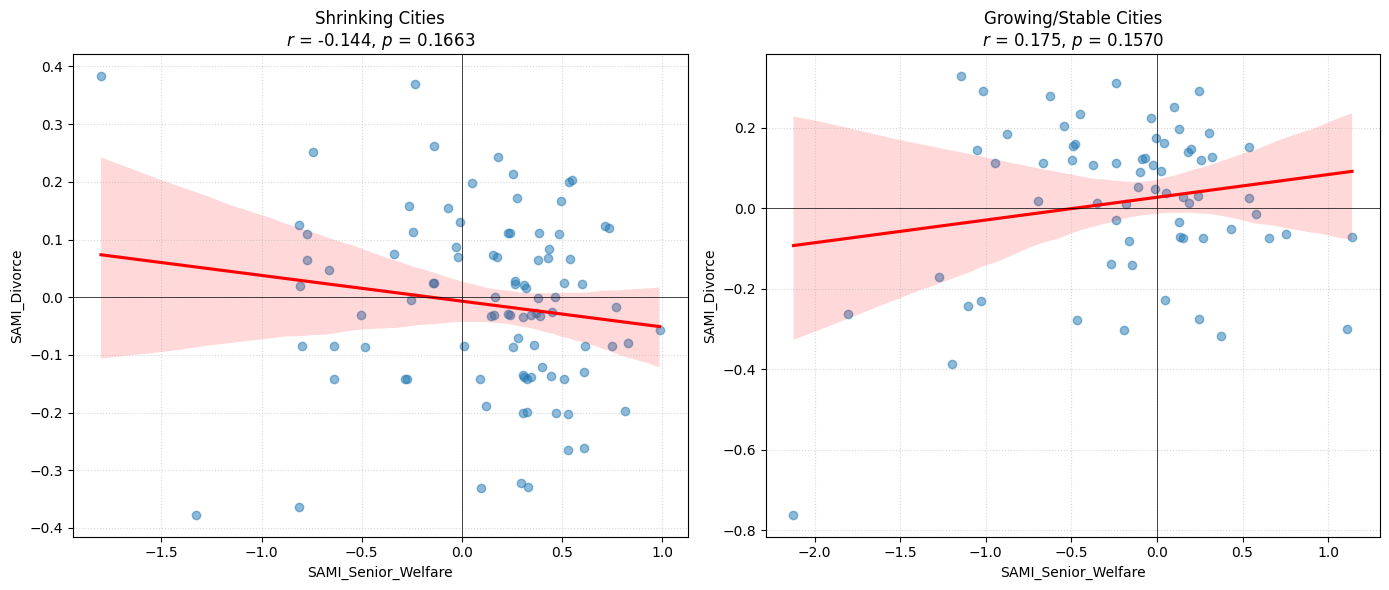

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# 1. 정제된 162개 도시 데이터셋 로드
load_path = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/Master_SAMI_Final_Clean_162.csv'
df_162 = pd.read_csv(load_path)

# 2. 2023년 기준 데이터 추출 및 그룹화 (Threshold: 0.90)
df_2023 = df_162[df_162['Year'] == 2023].copy()
peak_pop = df_162.groupby('City_name')['Population'].max().reset_index()
peak_pop.columns = ['City_name', 'Peak_Population']

df_group = pd.merge(df_2023, peak_pop, on='City_name', how='left')
df_group['Peak_Ratio'] = df_group['Population'] / df_group['Peak_Population']
df_group['Status'] = np.where(df_group['Peak_Ratio'] < 0.90, 'Shrinking', 'Growing/Stable')

# 3. 그룹별 상관관계 비교 함수
pathology_vars = ['SAMI_Crime', 'SAMI_Suicide', 'SAMI_Divorce', 'SAMI_Stress']
resilience_vars = ['SAMI_Doctor', 'SAMI_Social_Welfare', 'SAMI_Senior_Welfare']

def get_group_correlations(df, status_label):
    group_df = df[df['Status'] == status_label]
    corr_matrix = pd.DataFrame(index=pathology_vars, columns=resilience_vars)

    for p in pathology_vars:
        for r in resilience_vars:
            valid_pair = group_df[[p, r]].dropna()
            if len(valid_pair) > 5:
                r_val, p_val = pearsonr(valid_pair[p], valid_pair[r])
                sig = '*' if p_val < 0.05 else ''
                corr_matrix.loc[p, r] = f"{r_val:.3f}{sig}"
            else:
                corr_matrix.loc[p, r] = "N/A"
    return corr_matrix

# 4. 결과 출력
print(f"--- [2023년] 그룹별 SAMI 상관관계 비교 (N_Shrinking={len(df_group[df_group['Status']=='Shrinking'])}, N_Growing={len(df_group[df_group['Status']=='Growing/Stable'])}) ---")

print("\n[Shrinking Cities Group]")
print(get_group_correlations(df_group, 'Shrinking'))

print("\n[Growing/Stable Cities Group]")
print(get_group_correlations(df_group, 'Growing/Stable'))

# 5. 시각화 (노인복지시설 vs 이혼 상관관계 비교)
def compare_scatter(df, x_var, y_var):
    plt.figure(figsize=(14, 6))

    for i, status in enumerate(['Shrinking', 'Growing/Stable']):
        plt.subplot(1, 2, i+1)
        subset = df[df['Status'] == status].dropna(subset=[x_var, y_var])
        r_val, p_val = pearsonr(subset[x_var], subset[y_var])

        sns.regplot(data=subset, x=x_var, y=y_var,
                    scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
        plt.title(f'{status} Cities\n$r$ = {r_val:.3f}, $p$ = {p_val:.4f}')
        plt.axhline(0, color='black', lw=0.5); plt.axvline(0, color='black', lw=0.5)
        plt.grid(True, linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()

# 가설이 가장 선명하게 나타날 것으로 예상되는 조합 시각화
compare_scatter(df_group, 'SAMI_Senior_Welfare', 'SAMI_Divorce')

# SAMI 상호작용분석


 Dependent Variable: SAMI_Crime | Independent Variable: SAMI_Senior_Welfare
                                  Coefficient  p-value
Intercept                              0.0470   0.2998
SAMI_Senior_Welfare                    0.2196   0.0017
Is_Shrinking                          -0.0599   0.4358
SAMI_Senior_Welfare:Is_Shrinking      -0.2774   0.0343
R-squared: 0.118

 Dependent Variable: SAMI_Stress | Independent Variable: SAMI_Social_Welfare
                                  Coefficient  p-value
Intercept                              0.0114   0.4946
SAMI_Social_Welfare                    0.0279   0.3795
Is_Shrinking                          -0.0201   0.3535
SAMI_Social_Welfare:Is_Shrinking       0.0549   0.2581
R-squared: 0.041


<Figure size 1000x600 with 0 Axes>

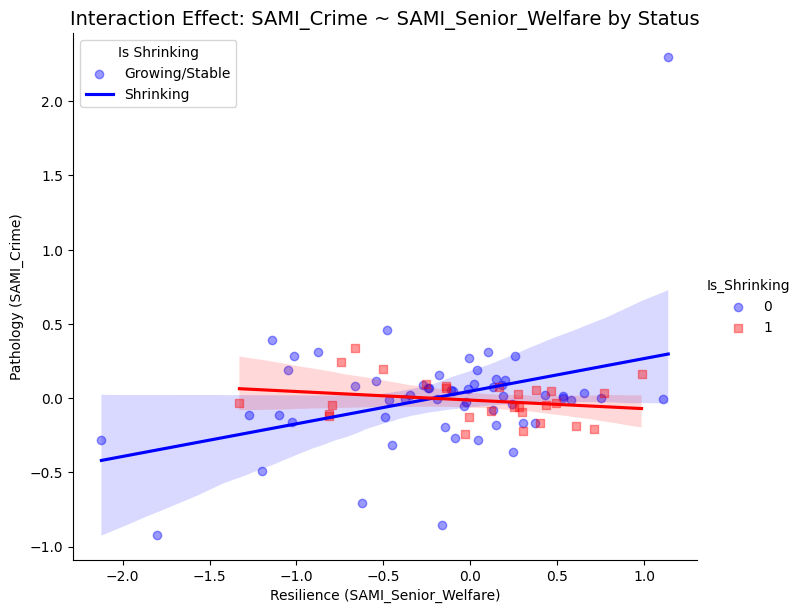

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드 및 전처리
load_path = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/Master_SAMI_Final_Clean_162.csv'
df_162 = pd.read_csv(load_path)

# 2023년 기준 그룹화 (Threshold: 0.90)
df_2023 = df_162[df_162['Year'] == 2023].copy()
peak_pop = df_162.groupby('City_name')['Population'].max().reset_index()
peak_pop.columns = ['City_name', 'Peak_Population']

df_model = pd.merge(df_2023, peak_pop, on='City_name', how='left')
df_model['Peak_Ratio'] = df_model['Population'] / df_model['Peak_Population']

# Shrinking을 1, Growing/Stable을 0으로 더미 변수화
df_model['Is_Shrinking'] = np.where(df_model['Peak_Ratio'] < 0.90, 1, 0)

# 2. 상호작용 모델 분석 함수
def run_interaction_model(dv, iv):
    # 모델식: DV ~ IV * Moderator (IV + Moderator + IV:Moderator)
    formula = f"{dv} ~ {iv} * Is_Shrinking"
    model = smf.ols(formula=formula, data=df_model).fit()

    print(f"\n" + "="*60)
    print(f" Dependent Variable: {dv} | Independent Variable: {iv}")
    print("="*60)
    # 주요 계수들만 출력 (Intercept, IV, Moderator, Interaction)
    summary_params = pd.concat([model.params, model.pvalues], axis=1)
    summary_params.columns = ['Coefficient', 'p-value']
    print(summary_params)
    print(f"R-squared: {model.rsquared:.3f}")

    return model

# 3. 주요 변수 조합 분석 실행
# 예: 범죄에 대한 노인복지시설의 효과가 쇠퇴 여부에 따라 달라지는가?
model_crime_senior = run_interaction_model('SAMI_Crime', 'SAMI_Senior_Welfare')

# 예: 스트레스에 대한 사회복지시설의 효과가 쇠퇴 여부에 따라 달라지는가?
model_stress_social = run_interaction_model('SAMI_Stress', 'SAMI_Social_Welfare')

# 4. 상호작용 시각화 (Interaction Plot)
def plot_interaction(dv, iv):
    plt.figure(figsize=(10, 6))
    sns.lmplot(x=iv, y=dv, hue='Is_Shrinking', data=df_model,
               palette={1: 'red', 0: 'blue'}, markers=["o", "s"],
               scatter_kws={'alpha':0.4}, height=6, aspect=1.2)

    plt.title(f'Interaction Effect: {dv} ~ {iv} by Status', fontsize=14)
    plt.xlabel(f'Resilience ({iv})')
    plt.ylabel(f'Pathology ({dv})')
    # 범례 수정: 1=Shrinking, 0=Growing
    plt.legend(title='Is Shrinking', labels=['Growing/Stable', 'Shrinking'])
    plt.show()

# 시각화 실행
plot_interaction('SAMI_Crime', 'SAMI_Senior_Welfare')

In [1]:
#@title 1인가구비율 데이터 없는 연도 선형보간

import pandas as pd
import numpy as np

# 1. 파일 로드
file_path = '/content/drive/MyDrive/Urban Scaling/vars/single-person household ratio.xlsx'
df_single = pd.read_excel(file_path)

# 2. 결측치 전처리: '-' 기호를 NaN으로 치환 및 숫자형 변환
# 식별 변수를 제외한 연도 데이터 열만 선택
year_cols = [col for col in df_single.columns if col not in ['City_name_Kor', 'City_Code']]

for col in year_cols:
    # 빈칸이나 '-' 기호를 통계적 결측치(NaN)로 변환 (문자열 섞임 방지)
    df_single[col] = pd.to_numeric(df_single[col].replace('-', np.nan), errors='coerce')

# 3. 식별자 인덱스 설정
df_single.set_index(['City_name_Kor', 'City_Code'], inplace=True)

# 4. 열 이름(연도) 정수형 변환 및 전체 연도(2000-2024) 빈칸 생성
df_single.columns = df_single.columns.astype(int)
full_years = list(range(2000, 2025))
df_single = df_single.reindex(columns=full_years)

# 5. 가로 방향(axis=1) 선형 보간 수행
df_interpolated = df_single.interpolate(method='linear', axis=1)

# 6. 인덱스 복구
df_interpolated.reset_index(inplace=True)

# 7. 보간 데이터 저장
save_path = '/content/drive/MyDrive/Urban Scaling/vars/single-person household ratio_interpolated.xlsx'
df_interpolated.to_excel(save_path, index=False)

print(f"결측치 전처리 및 선형 보간 완료: {save_path}")

결측치 전처리 및 선형 보간 완료: /content/drive/MyDrive/Urban Scaling/vars/single-person household ratio_interpolated.xlsx


/tmp/ipykernel_190/3539612463.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_single[col] = pd.to_numeric(df_single[col].replace('-', np.nan), errors='coerce')


In [2]:
#@title Net Migration Rate 계산
import pandas as pd
import numpy as np

# 1. 파일 경로 설정
path_migration = '/content/drive/MyDrive/Urban Scaling/vars/Net Migration Pop.xlsx'
path_population = '/content/drive/MyDrive/Urban Scaling/vars/Population_3.xlsx'

# 데이터 로드
df_mig = pd.read_excel(path_migration)
df_pop = pd.read_excel(path_population)

# 2. 전처리 함수 정의
def prepare_data(df, id_column):
    # 식별 변수를 제외한 연도 컬럼 추출 (정수형 또는 숫자로 변환 가능한 문자열)
    year_cols = [col for col in df.columns if str(col).isdigit()]

    # 결측치 기호 치환 및 숫자형 변환
    for col in year_cols:
        df[col] = pd.to_numeric(df[col].replace('-', np.nan), errors='coerce')

    # 식별 변수를 인덱스로 설정하고 연도 컬럼만 유지
    df_subset = df.set_index(id_column)[year_cols]

    # 연도 컬럼명을 정수형으로 통일
    df_subset.columns = df_subset.columns.astype(int)
    return df_subset

# 데이터 전처리 수행
df_mig_clean = prepare_data(df_mig, 'City_name_Kor')
df_pop_clean = prepare_data(df_pop, 'City_name_Kor')

# 3. 공통 연도 추출 및 데이터 정렬 (1995-2024)
common_years = sorted(list(set(df_mig_clean.columns) & set(df_pop_clean.columns)))

df_mig_common = df_mig_clean[common_years]
df_pop_common = df_pop_clean[common_years]

# 4. 순이동률 산출 (인덱스 및 컬럼 자동 매칭 연산)
df_rate_wide = (df_mig_common / df_pop_common) * 100

# 인덱스를 컬럼으로 복구
df_rate_wide = df_rate_wide.reset_index()

# 5. Wide format 저장
wide_save_path = '/content/drive/MyDrive/Urban Scaling/vars/Net_Migration_Rate_Wide.xlsx'
df_rate_wide.to_excel(wide_save_path, index=False)

# 6. Long format 변환
df_rate_long = df_rate_wide.melt(id_vars=['City_name_Kor'],
                                 var_name='Year',
                                 value_name='Net_Migration_Rate')

# 연도 데이터 타입 정수형 변환
df_rate_long['Year'] = df_rate_long['Year'].astype(int)

# 7. Long format 저장 (CSV 형식)
long_save_path = '/content/drive/MyDrive/Urban Scaling/vars/Net_Migration_Rate_Long.csv'
df_rate_long.to_csv(long_save_path, index=False, encoding='utf-8-sig')

print(f"Wide format 저장 경로: {wide_save_path}")
print(f"Long format 저장 경로: {long_save_path}")

Wide format 저장 경로: /content/drive/MyDrive/Urban Scaling/vars/Net_Migration_Rate_Wide.xlsx
Long format 저장 경로: /content/drive/MyDrive/Urban Scaling/vars/Net_Migration_Rate_Long.csv


/tmp/ipykernel_190/356638332.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = pd.to_numeric(df[col].replace('-', np.nan), errors='coerce')


In [3]:
#@title 노후주택비율 계산
import pandas as pd
import numpy as np
import glob
import os

# 1. 건축년도 변수명(ho_yr_XXX)을 (시작연도, 종료연도)로 매핑하는 함수
def get_year_range(var_name):
    try:
        num = int(str(var_name).split('_')[-1])
    except:
        return None, None

    if num == 1: return 1900, 1959 # 1959년 이전은 편의상 1900년으로 설정
    elif num == 2: return 1960, 1969
    elif num == 3: return 1970, 1979
    elif num == 4: return 1980, 1989
    elif num == 5: return 1990, 1994
    elif num == 6: return 1995, 1999
    elif num == 7: return 2000, 2004
    elif num >= 8:
        # ho_yr_008은 2005년, ho_yr_009는 2006년... 규칙 적용
        year = 1997 + num
        return year, year

    return None, None

# 2. 분석 연도 기준 30년 이상 주택의 비율(Fraction) 산출 함수
def get_old_fraction(var_name, current_year):
    start_year, end_year = get_year_range(var_name)
    if start_year is None:
        return 0.0

    target_year = current_year - 30

    if end_year <= target_year:
        return 1.0 # 전량 노후주택 포함
    elif start_year <= target_year < end_year:
        # 구간 내에 기준 연도가 걸칠 경우 균등분포 가정에 따른 비율 계산
        return (target_year - start_year + 1) / (end_year - start_year + 1)
    else:
        return 0.0 # 노후주택 미포함

# 3. 데이터 로드 및 결합
folder_path = '/content/drive/MyDrive/Urban Scaling/vars/건축년도별주택/'
# 폴더 내 모든 csv 파일 검색
all_files = glob.glob(os.path.join(folder_path, "*.csv"))

df_list = []
for file in all_files:
    # A~D열 구조에 맞추어 헤더 없이 로드 및 컬럼명 지정
    try:
        df_temp = pd.read_csv(file, header=None, names=['Year', 'Region_Code', 'Var_Name', 'House_Count'])
        df_list.append(df_temp)
    except Exception as e:
        print(f"파일 로드 오류 ({file}): {e}")

df_all = pd.concat(df_list, ignore_index=True)

# 결측치 또는 문자열(예: '-' 등) 처리
df_all['House_Count'] = pd.to_numeric(df_all['House_Count'].replace('-', np.nan), errors='coerce').fillna(0)

# 4. 노후주택 수 계산
df_all['Fraction'] = df_all.apply(lambda row: get_old_fraction(row['Var_Name'], row['Year']), axis=1)
df_all['Old_House_Count'] = df_all['House_Count'] * df_all['Fraction']

# 5. 연도 및 지역코드별 집계 (Total & Old Houses)
df_grouped = df_all.groupby(['Year', 'Region_Code']).agg(
    Total_Houses=('House_Count', 'sum'),
    Old_Houses=('Old_House_Count', 'sum')
).reset_index()

# 6. 노후주택비율 산출
df_grouped['Old_Housing_Ratio'] = (df_grouped['Old_Houses'] / df_grouped['Total_Houses']) * 100

# 7. 필요에 따라 기존 2015-2024 데이터와 형태를 맞추기 위해 Long Format 정비
# 최종 확인을 위해 출력
print("--- 노후주택비율 산출 결과 (샘플) ---")
print(df_grouped.head(10))

# 8. 산출된 데이터 저장
save_path = '/content/drive/MyDrive/Urban Scaling/vars/Old_Housing_Ratio_Calculated.csv'
df_grouped.to_csv(save_path, index=False, encoding='utf-8-sig')
print(f"산출 데이터 저장 완료: {save_path}")

--- 노후주택비율 산출 결과 (샘플) ---
   Year  Region_Code  Total_Houses  Old_Houses  Old_Housing_Ratio
0  2000           11     1916335.0    111420.6           5.814255
1  2000           21      805216.0     58023.7           7.205980
2  2000           22      540960.0     40679.4           7.519854
3  2000           23      614080.0     29425.5           4.791802
4  2000           24      324336.0     20915.2           6.448621
5  2000           25      320725.0     17819.6           5.556037
6  2000           26      229359.0      9925.1           4.327321
7  2000           29       25798.0      4476.1          17.350570
8  2000           31     2045296.0     89890.5           4.394987
9  2000           32      419288.0     68103.1          16.242559
산출 데이터 저장 완료: /content/drive/MyDrive/Urban Scaling/vars/Old_Housing_Ratio_Calculated.csv


In [4]:
#@title 노후주택비율 데이터셋(SGIS)에 있었던 도시코드와 도시명 맵핑(중간과정)
import pandas as pd

# 1. 파일 경로 설정
calc_data_path = '/content/drive/MyDrive/Urban Scaling/vars/Old_Housing_Ratio_Calculated.csv'
mapping_file_path = '/content/drive/MyDrive/Urban Scaling/Scaling Project Dataset Frame_city_list and code.xlsx'

# 2. 데이터 로드
df_old_housing = pd.read_csv(calc_data_path)
df_mapping = pd.read_excel(mapping_file_path)

# 3. 데이터 타입 통일 (병합 키 매칭을 위해 문자열로 변환)
# 소수점 등이 붙어있을 경우를 대비해 float -> int -> str 순으로 변환하는 것이 안전합니다.
df_old_housing['Region_Code'] = df_old_housing['Region_Code'].fillna(0).astype(int).astype(str)
df_mapping['City_Code'] = df_mapping['City_Code'].fillna(0).astype(int).astype(str)

# 4. 데이터 병합 (Left Join)
df_mapped = pd.merge(
    df_old_housing,
    df_mapping[['City_Code', 'City_name_Kor', 'city_name_Eng']],
    left_on='Region_Code',
    right_on='City_Code',
    how='inner' # 마스터 162개 도시에 해당하는 데이터만 추출하기 위해 inner join 사용
)

# 5. 매핑 결과 검증
# 원본 계산 데이터의 지역코드 고유 개수와 매핑된 데이터의 도시 개수 비교
original_code_count = df_old_housing['Region_Code'].nunique()
mapped_city_count = df_mapped['City_name_Kor'].nunique()

print(f"--- 매핑 결과 검증 ---")
print(f"계산된 원본 데이터 지역 개수: {original_code_count}개")
print(f"매핑 성공한 마스터 도시 개수: {mapped_city_count}개 / 162개")

if mapped_city_count < 162:
    print("\n경고: 일부 마스터 도시가 SGIS 지역코드와 매핑되지 않았습니다.")
    # 매핑되지 않은 도시명 도출
    mapped_cities = df_mapped['City_name_Kor'].unique()
    missing_cities = df_mapping[~df_mapping['City_name_Kor'].isin(mapped_cities)]['City_name_Kor'].unique()
    print("누락된 도시 목록:")
    print(missing_cities)

# 6. 분석용 최종 컬럼 정렬
final_cols = ['Year', 'City_Code', 'City_name_Kor', 'city_name_Eng', 'Total_Houses', 'Old_Houses', 'Old_Housing_Ratio']
df_final_housing = df_mapped[final_cols].sort_values(by=['City_name_Kor', 'Year'])

# 7. 결과 저장
save_path = '/content/drive/MyDrive/Urban Scaling/vars/Old_Housing_Ratio_Mapped.csv'
df_final_housing.to_csv(save_path, index=False, encoding='utf-8-sig')
print(f"\n최종 매핑 데이터 저장 완료: {save_path}")

--- 매핑 결과 검증 ---
계산된 원본 데이터 지역 개수: 3823개
매핑 성공한 마스터 도시 개수: 150개 / 162개

경고: 일부 마스터 도시가 SGIS 지역코드와 매핑되지 않았습니다.
누락된 도시 목록:
['경기도수원시' '경기도성남시' '경기도안양시' '경기도부천시' '경기도안산시' '경기도고양시' '경기도용인시' '충청북도청주시'
 '충청남도천안시' '전북특별자치도전주시' '경상북도포항시' '경상남도창원시']

최종 매핑 데이터 저장 완료: /content/drive/MyDrive/Urban Scaling/vars/Old_Housing_Ratio_Mapped.csv


In [5]:
#@title 노후주택비율 데이터셋(SGIS)에 있었던 도시코드와 도시명 맵핑(이어서)
import pandas as pd

# 1. 이전 단계에서 산출/로드한 파일 경로
calc_data_path = '/content/drive/MyDrive/Urban Scaling/vars/Old_Housing_Ratio_Calculated.csv'
mapping_file_path = '/content/drive/MyDrive/Urban Scaling/Scaling Project Dataset Frame_city_list and code.xlsx'

df_old_housing = pd.read_csv(calc_data_path)
df_mapping = pd.read_excel(mapping_file_path)

# 2. 데이터 타입 통일 (문자열 변환)
df_old_housing['Region_Code'] = df_old_housing['Region_Code'].fillna(0).astype(int).astype(str)
df_mapping['City_Code'] = df_mapping['City_Code'].fillna(0).astype(int).astype(str)

# 3. 누락된 대도시의 '구' 코드를 '시' 코드로 통합하는 함수 정의
master_codes = df_mapping['City_Code'].unique()

def map_district_to_city(code):
    # 이미 마스터 코드 162개에 정확히 존재하는 경우 (150개 도시)
    if code in master_codes:
        return code

    # 5자리 지역코드인 경우, 마지막 자리를 '0'으로 변경하여 부모 시 코드 확인
    if len(code) == 5:
        parent_code = code[:4] + '0'
        if parent_code in master_codes:
            return parent_code

    return code # 매핑 불가 시 원본 유지

# 4. 코드 변환 적용
df_old_housing['Mapped_Code'] = df_old_housing['Region_Code'].apply(map_district_to_city)

# 5. 변환된 코드를 기준으로 주택 수 합산 (구 단위 물량을 시 단위로 통합)
df_aggregated = df_old_housing.groupby(['Year', 'Mapped_Code']).agg(
    Total_Houses=('Total_Houses', 'sum'),
    Old_Houses=('Old_Houses', 'sum')
).reset_index()

# 6. 노후주택비율 재산출
df_aggregated['Old_Housing_Ratio'] = (df_aggregated['Old_Houses'] / df_aggregated['Total_Houses']) * 100

# 7. 마스터 데이터와 최종 병합
df_mapped_final = pd.merge(
    df_aggregated,
    df_mapping[['City_Code', 'City_name_Kor', 'city_name_Eng']],
    left_on='Mapped_Code',
    right_on='City_Code',
    how='inner'
)

# 8. 매핑 결과 재검증
mapped_city_count = df_mapped_final['City_name_Kor'].nunique()
print(f"--- 매핑 결과 재검증 ---")
print(f"매핑 성공한 마스터 도시 개수: {mapped_city_count}개 / 162개")

if mapped_city_count == 162:
    print("통합 성공: 12개 대도시 구 데이터가 시 단위로 병합되었습니다.")
else:
    mapped_cities = df_mapped_final['City_name_Kor'].unique()
    missing_cities = df_mapping[~df_mapping['City_name_Kor'].isin(mapped_cities)]['City_name_Kor'].unique()
    print(f"누락된 도시 목록: {missing_cities}")

# 9. 최종 저장 (2000, 2005, 2010년 데이터)
final_cols = ['Year', 'City_Code', 'City_name_Kor', 'city_name_Eng', 'Total_Houses', 'Old_Houses', 'Old_Housing_Ratio']
df_final_housing = df_mapped_final[final_cols].sort_values(by=['City_name_Kor', 'Year'])

save_path = '/content/drive/MyDrive/Urban Scaling/vars/Old_Housing_Ratio_Mapped_Final.csv'
df_final_housing.to_csv(save_path, index=False, encoding='utf-8-sig')
print(f"\n최종 통합 데이터 저장 완료: {save_path}")

--- 매핑 결과 재검증 ---
매핑 성공한 마스터 도시 개수: 162개 / 162개
통합 성공: 12개 대도시 구 데이터가 시 단위로 병합되었습니다.

최종 통합 데이터 저장 완료: /content/drive/MyDrive/Urban Scaling/vars/Old_Housing_Ratio_Mapped_Final.csv


In [6]:
import pandas as pd
import numpy as np

# 1. 데이터 로드
# 앞서 SGIS 데이터로 산출한 2000, 2005, 2010년 앵커 데이터
path_anchor = '/content/drive/MyDrive/Urban Scaling/vars/Old_Housing_Ratio_Mapped_Final.csv'
df_anchor = pd.read_csv(path_anchor)

# 기존에 보유하신 2015-2024년 와이드 포맷 데이터
path_recent = '/content/drive/MyDrive/Urban Scaling/vars/Old Housing Ratio_2015_2024.xlsx'
df_recent_wide = pd.read_excel(path_recent)

# 2. 2015-2024년 데이터 전처리 (Wide to Long)
# 숫자로 된 연도 헤더(2015, 2016... 2024)만 컬럼명으로 추출
year_cols = [col for col in df_recent_wide.columns if str(col).isdigit() and 2015 <= int(col) <= 2024]

# 필요한 컬럼(도시명과 연도 데이터)만 서브셋으로 추출
df_recent_sub = df_recent_wide[['City_name_Kor'] + year_cols].copy()

# Melt를 통해 롱 포맷으로 변환
df_recent_long = df_recent_sub.melt(id_vars=['City_name_Kor'],
                                    var_name='Year',
                                    value_name='Old_Housing_Ratio')

# 연도 컬럼을 정수형으로 통일, 결측치 기호('-') 처리 및 숫자형 변환
df_recent_long['Year'] = df_recent_long['Year'].astype(int)
df_recent_long['Old_Housing_Ratio'] = pd.to_numeric(df_recent_long['Old_Housing_Ratio'].replace('-', np.nan), errors='coerce')

# 3. 앵커 데이터와 최근 데이터의 구조를 동일하게 맞추고 병합
df_anchor_sub = df_anchor[['City_name_Kor', 'Year', 'Old_Housing_Ratio']].copy()

# 세로 결합 (2000, 2005, 2010, 2015~2024년이 모두 포함된 상태)
df_combined = pd.concat([df_anchor_sub, df_recent_long], ignore_index=True)

# 4. 보간을 위한 완전한 패널 그리드(162개 도시 x 25개 연도) 생성
cities = df_anchor_sub['City_name_Kor'].unique()
years = list(range(2000, 2025))

# MultiIndex를 활용해 모든 경우의 수를 가진 빈 데이터프레임 생성
grid = pd.MultiIndex.from_product([cities, years], names=['City_name_Kor', 'Year']).to_frame(index=False)

# 기존 결합 데이터와 병합 (비어있는 2001~2004, 2006~2009, 2011~2014년은 NaN으로 들어감)
df_full_grid = pd.merge(grid, df_combined, on=['City_name_Kor', 'Year'], how='left')

# 5. 도시별 선형 보간 수행
# City_name_Kor 기준으로 그룹화한 뒤 연도순으로 선형 보간
df_full_grid = df_full_grid.sort_values(by=['City_name_Kor', 'Year'])
df_full_grid['Old_Housing_Ratio'] = df_full_grid.groupby('City_name_Kor')['Old_Housing_Ratio'].transform(
    lambda group: group.interpolate(method='linear')
)

# 6. 최종 데이터 확인 및 저장
print("--- 결측치 보간 완료 ---")
print(f"전체 결측치 개수: {df_full_grid['Old_Housing_Ratio'].isnull().sum()}")

# 서울특별시 샘플 확인 (보간이 잘 되었는지 점검)
sample_city = df_full_grid[df_full_grid['City_name_Kor'] == '서울특별시'].head(16)
print("\n--- 서울특별시 보간 결과 샘플 (2000-2015) ---")
print(sample_city)

save_path = '/content/drive/MyDrive/Urban Scaling/vars/Old_Housing_Ratio_Panel_Final.csv'
df_full_grid.to_csv(save_path, index=False, encoding='utf-8-sig')
print(f"\n최종 노후주택비율 패널 저장 완료: {save_path}")

/tmp/ipykernel_190/1926372642.py:27: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_recent_long['Old_Housing_Ratio'] = pd.to_numeric(df_recent_long['Old_Housing_Ratio'].replace('-', np.nan), errors='coerce')


--- 결측치 보간 완료 ---
전체 결측치 개수: 0

--- 서울특별시 보간 결과 샘플 (2000-2015) ---
     City_name_Kor  Year  Old_Housing_Ratio
3290         서울특별시  2000           5.814255
3291         서울특별시  2001           6.084698
3292         서울특별시  2002           6.355141
3293         서울특별시  2003           6.625584
3294         서울특별시  2004           6.896027
3295         서울특별시  2005           7.166470
3296         서울특별시  2006           7.595975
3297         서울특별시  2007           8.025481
3298         서울특별시  2008           8.454987
3299         서울특별시  2009           8.884492
3300         서울특별시  2010           9.313998
3301         서울특별시  2011          20.715623
3302         서울특별시  2012          32.117249
3303         서울특별시  2013          43.518874
3304         서울특별시  2014          54.920500
3305         서울특별시  2015          66.322125

최종 노후주택비율 패널 저장 완료: /content/drive/MyDrive/Urban Scaling/vars/Old_Housing_Ratio_Panel_Final.csv


In [7]:
import pandas as pd
import numpy as np

# 1. 파일별 입출력 경로 및 변수명 매핑 딕셔너리
file_info = {
    'Single_HH': {
        'input': '/content/drive/MyDrive/Urban Scaling/vars/single-person household ratio_interpolated.xlsx',
        'output': '/content/drive/MyDrive/Urban Scaling/vars/Single_HH_Ratio_Long.csv',
        'value_name': 'Single_HH_Ratio'
    },
    'Elderly': {
        'input': '/content/drive/MyDrive/Urban Scaling/vars/elderly pop percentage.xlsx',
        'output': '/content/drive/MyDrive/Urban Scaling/vars/Elderly_Ratio_Long.csv',
        'value_name': 'Elderly_Ratio'
    },
    'GRDP': {
        'input': '/content/drive/MyDrive/Urban Scaling/vars/GRDP_Data_162.xlsx',
        'output': '/content/drive/MyDrive/Urban Scaling/vars/GRDP_Long.csv',
        'value_name': 'GRDP'
    },
    'Fin_Indep': {
        'input': '/content/drive/MyDrive/Urban Scaling/vars/Financial Independence Rate_개편전_2001-2025_162.xlsx',
        'output': '/content/drive/MyDrive/Urban Scaling/vars/Financial_Independence_Long.csv',
        'value_name': 'Financial_Independence'
    }
}

# 2. 일괄 변환 및 컬럼명 정비 함수 정의
def convert_all_to_long(info_dict):
    for key, info in info_dict.items():
        try:
            # 데이터 로드
            df = pd.read_excel(info['input'])

            # 연도 컬럼(숫자형태)과 식별자 컬럼 자동 분리
            year_cols = [col for col in df.columns if str(col).isdigit() and 1990 <= int(col) <= 2030]
            id_cols = [col for col in df.columns if col not in year_cols]

            # 롱 포맷 변환 (Melt)
            df_long = df.melt(id_vars=id_cols,
                              value_vars=year_cols,
                              var_name='Year',
                              value_name=info['value_name'])

            # 데이터 타입 정비 및 결측치 기호(-) 처리
            df_long['Year'] = df_long['Year'].astype(int)
            df_long[info['value_name']] = pd.to_numeric(
                df_long[info['value_name']].replace('-', np.nan), errors='coerce'
            )

            # 마스터 패널과의 완벽한 병합을 위해 컬럼명 변경 (City_name_Kor -> City_name)
            if 'City_name_Kor' in df_long.columns:
                df_long = df_long.rename(columns={'City_name_Kor': 'City_name'})

            # 결과 저장
            df_long.to_csv(info['output'], index=False, encoding='utf-8-sig')
            print(f"변환 및 컬럼명 수정 완료 ({key}): {info['output']}")

        except Exception as e:
            print(f"변환 실패 ({key}): {e}")

# 3. 함수 실행
convert_all_to_long(file_info)

변환 및 컬럼명 수정 완료 (Single_HH): /content/drive/MyDrive/Urban Scaling/vars/Single_HH_Ratio_Long.csv
변환 및 컬럼명 수정 완료 (Elderly): /content/drive/MyDrive/Urban Scaling/vars/Elderly_Ratio_Long.csv
변환 및 컬럼명 수정 완료 (GRDP): /content/drive/MyDrive/Urban Scaling/vars/GRDP_Long.csv
변환 및 컬럼명 수정 완료 (Fin_Indep): /content/drive/MyDrive/Urban Scaling/vars/Financial_Independence_Long.csv


In [10]:
#@title 마스터패널에 통제변수 병합


import pandas as pd

# 1. 마스터 데이터셋 로드
master_path = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/Master_SAMI_Final_Clean_162.csv'
df_master = pd.read_csv(master_path)

# 2. 통제변수 파일 경로 설정 (순이동률 경로 수정 반영)
control_files = {
    'Net_Migration': {
        'path': '/content/drive/MyDrive/Urban Scaling/vars/Net_Migration_Rate_Long.csv', # 실제 위치에 따라 vars/ 추가 필요
        'var_name': 'Net_Migration_Rate'
    },
    'Old_Housing': {
        'path': '/content/drive/MyDrive/Urban Scaling/vars/Old_Housing_Ratio_Panel_Final.csv',
        'var_name': 'Old_Housing_Ratio'
    },
    'Single_HH': {
        'path': '/content/drive/MyDrive/Urban Scaling/vars/Single_HH_Ratio_Long.csv',
        'var_name': 'Single_HH_Ratio'
    },
    'Elderly': {
        'path': '/content/drive/MyDrive/Urban Scaling/vars/Elderly_Ratio_Long.csv',
        'var_name': 'Elderly_Ratio'
    },
    'GRDP': {
        'path': '/content/drive/MyDrive/Urban Scaling/vars/GRDP_Long.csv',
        'var_name': 'GRDP'
    },
    'Fin_Indep': {
        'path': '/content/drive/MyDrive/Urban Scaling/vars/Financial_Independence_Long.csv',
        'var_name': 'Financial_Independence'
    }
}

# 3. 순차적 병합 수행
df_integrated = df_master.copy()
added_vars = []

for key, info in control_files.items():
    try:
        df_control = pd.read_csv(info['path'])

        # 식별자 변수명 통일
        if 'City_name_Kor' in df_control.columns:
            df_control = df_control.rename(columns={'City_name_Kor': 'City_name'})

        df_control['Year'] = df_control['Year'].astype(int)

        # 병합 (Left Join)
        cols_to_merge = ['City_name', 'Year', info['var_name']]
        df_integrated = pd.merge(
            df_integrated,
            df_control[cols_to_merge],
            on=['City_name', 'Year'],
            how='left'
        )
        added_vars.append(info['var_name'])
        print(f"병합 완료: {key} ({info['var_name']})")

    except Exception as e:
        print(f"병합 실패 ({key}): {e}")

# 4. 결측치 연도별 교차 검증
print("\n--- 통제변수 전체 결측치 요약 ---")
print(df_integrated[added_vars].isnull().sum())

print("\n--- 연도별 통제변수 결측치 현황 ---")
missing_by_year = df_integrated.groupby('Year')[added_vars].apply(lambda x: x.isnull().sum())
print(missing_by_year.to_string())

# 5. 최종 데이터 저장
save_path = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/Master_Panel_Integrated.csv'
df_integrated.to_csv(save_path, index=False, encoding='utf-8-sig')
print(f"\n최종 마스터 패널 저장 완료: {save_path}")

병합 완료: Net_Migration (Net_Migration_Rate)
병합 완료: Old_Housing (Old_Housing_Ratio)
병합 완료: Single_HH (Single_HH_Ratio)
병합 완료: Elderly (Elderly_Ratio)
병합 완료: GRDP (GRDP)
병합 완료: Fin_Indep (Financial_Independence)

--- 통제변수 전체 결측치 요약 ---
Net_Migration_Rate          10
Old_Housing_Ratio          324
Single_HH_Ratio            329
Elderly_Ratio              332
GRDP                      1587
Financial_Independence     486
dtype: int64

--- 연도별 통제변수 결측치 현황 ---
      Net_Migration_Rate  Old_Housing_Ratio  Single_HH_Ratio  Elderly_Ratio  GRDP  Financial_Independence
Year                                                                                                     
1998                   2                162              162            162   162                     162
1999                   2                162              162            162   162                     162
2000                   2                  0                1              4    94                     162
2001          

In [2]:
import pandas as pd

# 1. 마스터 데이터셋 로드
master_path = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/Master_SAMI_Final_Clean_162.csv'
df_master = pd.read_csv(master_path)

# [진단 1] 마스터 데이터셋 자체에 중복이 있는지 확인
master_dups = df_master.duplicated(subset=['City_name', 'Year']).sum()
if master_dups > 0:
    print(f"🚨 원인 발견: 마스터 데이터셋 자체에 {master_dups}개의 중복 행이 있습니다!")
    # 중복 행 제거 (첫 번째 행만 유지)
    df_master = df_master.drop_duplicates(subset=['City_name', 'Year'], keep='first')


In [4]:

# 2. 통제변수 파일 경로 설정
control_files = {
    'Net_Migration': {'path': '/content/drive/MyDrive/Urban Scaling/vars/Net_Migration_Rate_Long.csv', 'var_name': 'Net_Migration_Rate'},
    'Old_Housing': {'path': '/content/drive/MyDrive/Urban Scaling/vars/Old_Housing_Ratio_Panel_Final.csv', 'var_name': 'Old_Housing_Ratio'},
    'Single_HH': {'path': '/content/drive/MyDrive/Urban Scaling/vars/Single_HH_Ratio_Long.csv', 'var_name': 'Single_HH_Ratio'},
    'Elderly': {'path': '/content/drive/MyDrive/Urban Scaling/vars/Elderly_Ratio_Long.csv', 'var_name': 'Elderly_Ratio'},
    'GRDP': {'path': '/content/drive/MyDrive/Urban Scaling/vars/GRDP_Long.csv', 'var_name': 'GRDP'},
    'Fin_Indep': {'path': '/content/drive/MyDrive/Urban Scaling/vars/Financial_Independence_Long.csv', 'var_name': 'Financial_Independence'}
}

# 3. 순차적 병합 (Left Join)
df_integrated = df_master.copy()
added_vars = []

for key, info in control_files.items():
    try:
        df_control = pd.read_csv(info['path'])

        if 'City_name_Kor' in df_control.columns:
            df_control = df_control.rename(columns={'City_name_Kor': 'City_name'})

        df_control['Year'] = df_control['Year'].astype(int)

        # [진단 2] 통제변수 파일에 중복이 있는지 확인
        control_dups = df_control.duplicated(subset=['City_name', 'Year']).sum()
        if control_dups > 0:
            print(f"🚨 원인 발견: {key} 통제변수 파일에 {control_dups}개의 중복 행이 있습니다!")
            df_control = df_control.drop_duplicates(subset=['City_name', 'Year'], keep='first')

        # 안전한 병합 수행
        cols_to_merge = ['City_name', 'Year', info['var_name']]
        df_integrated = pd.merge(
            df_integrated,
            df_control[cols_to_merge],
            on=['City_name', 'Year'],
            how='left'
        )
        added_vars.append(info['var_name'])
        print(f"✅ 병합 완료: {key} ({info['var_name']})")

    except Exception as e:
        print(f"❌ 병합 실패 ({key}): {e}")

# 4. 결측치 연도별 교차 검증 (정상화 확인)
print("\n--- 통제변수 전체 결측치 요약 ---")
print(df_integrated[added_vars].isnull().sum())

print("\n--- 연도별 통제변수 결측치 현황 ---")
missing_by_year = df_integrated.groupby('Year')[added_vars].apply(lambda x: x.isnull().sum())
print(missing_by_year.tail(10).to_string()) # 최근 10년만 출력하여 가독성 확보

# 5. 최종 데이터 저장
save_path = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/Master_Panel_Integrated.csv'
df_integrated.to_csv(save_path, index=False, encoding='utf-8-sig')
print(f"\n최종 마스터 패널 저장 완료: {save_path}")

✅ 병합 완료: Net_Migration (Net_Migration_Rate)
🚨 원인 발견: Old_Housing 통제변수 파일에 1620개의 중복 행이 있습니다!
✅ 병합 완료: Old_Housing (Old_Housing_Ratio)
✅ 병합 완료: Single_HH (Single_HH_Ratio)
✅ 병합 완료: Elderly (Elderly_Ratio)
✅ 병합 완료: GRDP (GRDP)
✅ 병합 완료: Fin_Indep (Financial_Independence)

--- 통제변수 전체 결측치 요약 ---
Net_Migration_Rate          10
Old_Housing_Ratio          324
Single_HH_Ratio            329
Elderly_Ratio              332
GRDP                      1271
Financial_Independence     486
dtype: int64

--- 연도별 통제변수 결측치 현황 ---
      Net_Migration_Rate  Old_Housing_Ratio  Single_HH_Ratio  Elderly_Ratio  GRDP  Financial_Independence
Year                                                                                                     
2015                   0                  0                0              0     0                       0
2016                   0                  0                0              0     0                       0
2017                   0                  0                

In [5]:
# 최근 10년 제한(tail)을 해제하고 전체 연도 결측치 출력
print(missing_by_year.to_string())

      Net_Migration_Rate  Old_Housing_Ratio  Single_HH_Ratio  Elderly_Ratio  GRDP  Financial_Independence
Year                                                                                                     
1998                   2                162              162            162   162                     162
1999                   2                162              162            162   162                     162
2000                   2                  0                1              4    94                     162
2001                   2                  0                1              2    94                       0
2002                   2                  0                1              2    94                       0
2003                   0                  0                1              0    93                       0
2004                   0                  0                1              0    93                       0
2005                   0                  0   

In [6]:
df_integrated.columns

Index(['City_name', 'Year', 'UPI', 'Population', 'Suicide_Rate_100k',
       'Crude_Divorce_Rate_1k', 'Stress_Rate', 'Total_Crime_Count',
       'Crime_Count_Drug', 'Crime_Count_Economic', 'Crime_Count_Heinous',
       'Crime_Count_Morality', 'Crime_Count_Theft', 'Crime_Count_Violent',
       'Crime_Count_White-collar', 'Suicide_Count', 'Divorce_Count', 'log_Pop',
       'log_UPI', 'log_Suicide', 'log_Divorce', 'log_Total_Crime_Count',
       'log_Crime_Count_Drug', 'log_Crime_Count_Economic',
       'log_Crime_Count_Heinous', 'log_Crime_Count_Morality',
       'log_Crime_Count_Theft', 'log_Crime_Count_Violent',
       'log_Crime_Count_White-collar', 'Stress_Count', 'log_Stress',
       'Crime_Count_excl_Drug', 'log_Crime_excl_Drug', 'SAMI_Crime',
       'SAMI_Suicide', 'SAMI_Divorce', 'SAMI_Stress', 'Doctor_Count',
       'Social_Welfare_Count', 'Senior_Welfare_Count', 'log_Doctor',
       'log_Social_Welfare', 'log_Senior_Welfare', 'SAMI_Doctor',
       'SAMI_Social_Welfare', 'SAMI_S

In [7]:
#@title 변수간 다중공선성 검증(VIF)
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. 마스터 패널 로드
master_path = '/content/drive/MyDrive/Urban Scaling/Grid Pop Data/Master_Panel_Integrated.csv'
df = pd.read_csv(master_path)

# 2. 검증할 통제변수 리스트
control_vars = [
    'Net_Migration_Rate',
    'Old_Housing_Ratio',
    'Single_HH_Ratio',
    'Elderly_Ratio',
    'GRDP',
    'Financial_Independence'
]

# 3. 결측치가 없는 구간을 기준으로 데이터 필터링 (VIF는 결측치가 있으면 계산 불가)
df_vif = df.dropna(subset=control_vars)

# 4. 상수항 추가 (VIF 계산의 통계적 엄밀성을 위해 필수)
X = sm.add_constant(df_vif[control_vars])

# 5. VIF 계산
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# 결과 출력 (상수항 const는 무시하고 통제변수들의 VIF 수치만 확인)
print("--- 통제변수 다중공선성(VIF) 검증 결과 ---")
print(vif_data[vif_data['Variable'] != 'const'].round(2).to_string(index=False))

--- 통제변수 다중공선성(VIF) 검증 결과 ---
              Variable  VIF
    Net_Migration_Rate 1.10
     Old_Housing_Ratio 2.23
       Single_HH_Ratio 3.70
         Elderly_Ratio 4.24
                  GRDP 1.75
Financial_Independence 3.47
